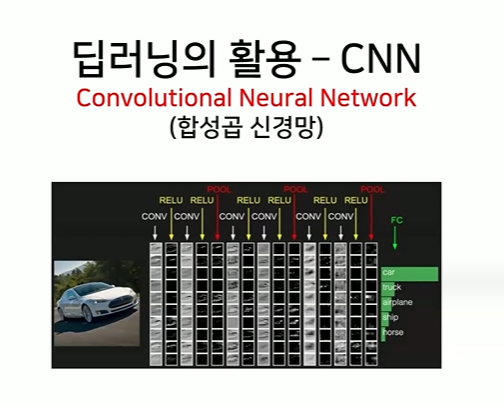

In [ ]:
# CNN : 이미지 또는 영상데이터를 처리하는데 특화된 인공신경망 알고리즘
# 이미지를 가로, 세로, 2차원 형태 그대로 컴퓨터에 집어넣는다.
# 픽셀 단위의 정보를 가진 '디지털 이미지'를 대상으로 한다.

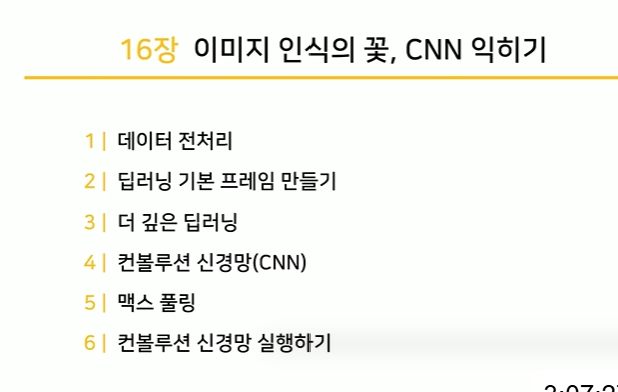

In [ ]:
# 패턴 매칭
# 초기 똑같은 크기, 똑같은 기울기만 가능하다는 단점

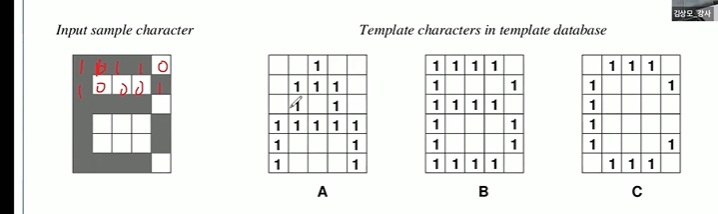

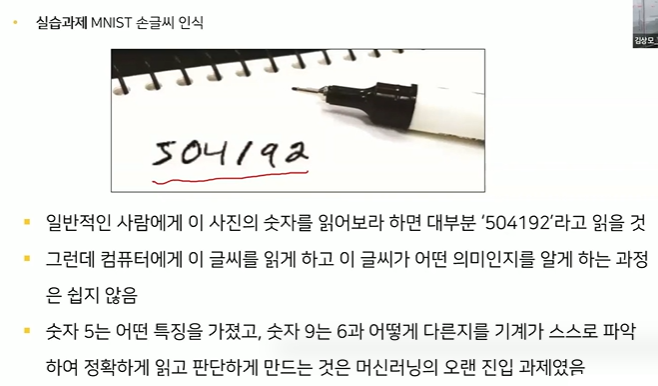

In [ ]:
# mnist : 손 글씨 dataset
# 0~9까지 
# 70000개

In [8]:
from tensorflow.keras.datasets import mnist

(X_train, Y_class_train), (X_test, Y_class_test) = mnist.load_data()

print("학습셋 이미지 수 : %d 개" % (X_train.shape[0]))
print("테스트셋 이미지 수 : %d 개" % (X_test.shape[0]))

학습셋 이미지 수 : 60000 개
테스트셋 이미지 수 : 10000 개


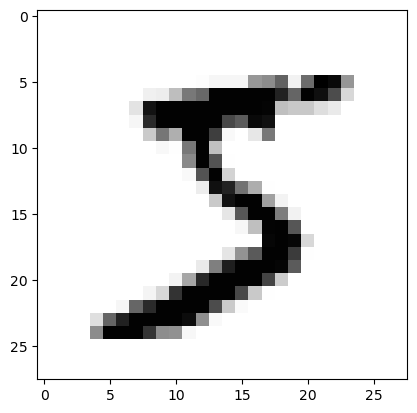

In [10]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap='Greys')
plt.show()

In [ ]:
# 가로(28) x 세로(28) = 총 784개의 픽셀로 이루어진 이미지
# 각 픽셀은 밝기 정도에 따라, 0~255까지 등급을 매긴다.
# 흰색 배경이 0이라면, 글씨가 들어간 곳은 1~255까지의 숫자 중 하나로 채워진다.   

In [15]:
import sys
for x in X_train[0]:
    for i in x:
        sys.stdout.write('%3d' % i) # sys.stdout.write('%d\t' % i)
    sys.stdout.write('\n') 

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0  

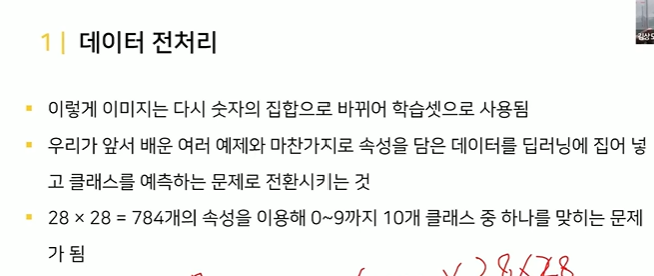

In [ ]:
from tensorflow.keras.datasets import mnist

(X_trian, Y_class_train), (X_test, Y_class_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255
Y_train = tf.keras.utils.to_categorical(Y_class_train, 10)
Y_test = tf.keras.utils.to_categorical(Y_class_test, 10)

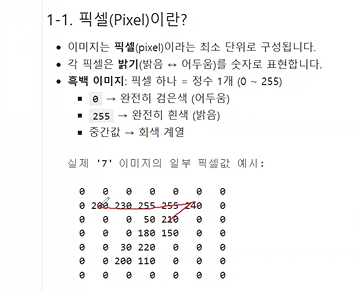

In [ ]:
# MNIST 데이터셋
# 각 이미지 28 x 28 픽셀(흑백일 경우)
# 훈련 데이터 60,000장 / 테스트 데이터 10,000장

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

image = x_train[0]

print("라벨:", y_train[0])
print("픽셀값 범위:", image.min(), "~", image.max())

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray') # cmap 라이브러리에 따라 다르다.
plt.title("gra\n0=black, 255=white")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image, cmap='Greys') # cmap 라이브러리에 따라 다르다.
plt.title("Greys\n0=white, 255=black")
plt.axis('off')

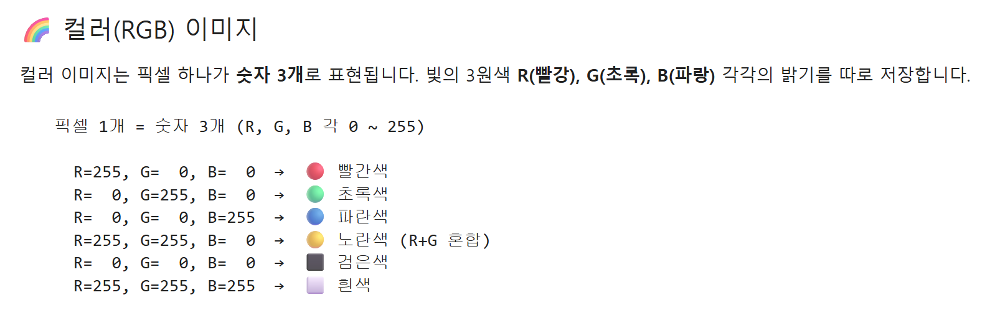

In [ ]:
# shape : (28, 28, 3) <- 채널(R, G, B)

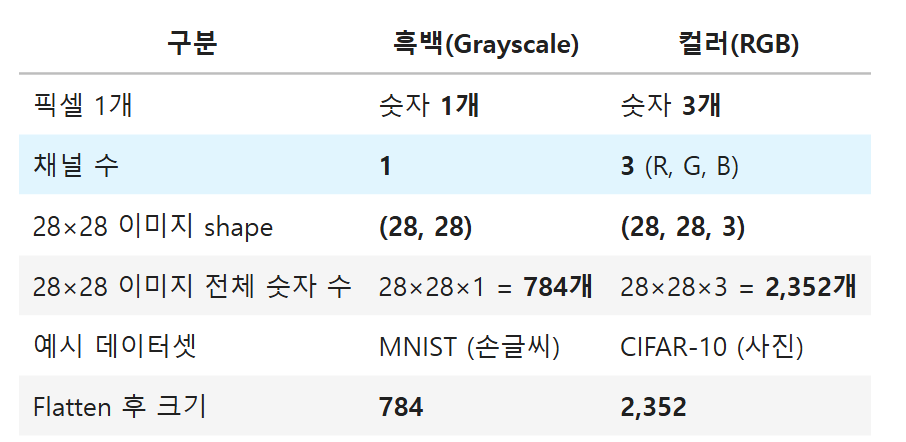

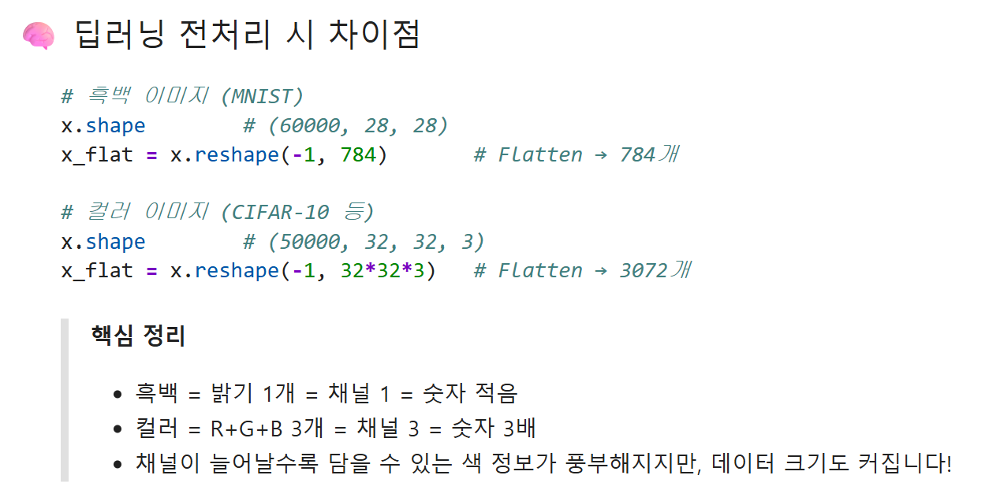

In [ ]:
# 1.필요한 라이브러리 임포트

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Keras(Tensorflow 내장)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# 한글 폰트 설정(한글 깨짐 방지)
# Window 사용자 : 'Malgun Gothic', Mac 사용자 : 'AppleGothic'
import matplotlib.font_manager as fm
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux(colab 등)
    # Colab 환경에서 한글 폰트 설치 필요 시 아래 주석 해제
    # !apt-get install -y fonts-nanum > /dev/null
    # fm._load_fontmanager(try_read_cache=False)
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("✅ 라이브러리 임포트 완료")
print(f" 현재 운영체제: {platform.system()}")
print(f" 현재 폰트: {plt.rcParams['font.family']}")

✅ 라이브러리 임포트 완료
 현재 운영체제: Windows
 현재 폰트: ['Malgun Gothic']


In [ ]:
# 2.이미지 = 행렬(2D숫자 배열) 직접 확인

In [3]:
# MNIST 데이터 로드 및 원본 구조 확인
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

print("=" * 50)
print("📦 MNIST 데이터셋 로드 완료")
print("=" * 50)
print(f"훈련 이미지 shape : {x_train_raw.shape}")
# (60000, 28, 28) : 60000장, 각 이미지는 28행 x 28열
print(f"훈련 레이블 shape : {y_train_raw.shape}")
# (60000,) : 0 ~ 9까지의 숫자 datasets인 mnist 라이브러리 -> 각 이미지에 대응하는 0 ~ 9까지의 숫자 60000개
print(f"테스트 이미지 shape : {x_test_raw.shape}")
print(f"테스트 레이블 shape : {y_test_raw.shape}")
print()
print(f"픽셀값 데이터 타입 : {x_train_raw.dtype}") # unit8
print(f"픽셀값 최소값 : {x_train_raw.min()}")
print(f"픽셀값 최대값 : {x_train_raw.max()}")

📦 MNIST 데이터셋 로드 완료
훈련 이미지 shape : (60000, 28, 28)
훈련 레이블 shape : (60000,)
테스트 이미지 shape : (10000, 28, 28)
테스트 레이블 shape : (10000,)

픽셀값 데이터 타입 : uint8
픽셀값 최소값 : 0
픽셀값 최대값 : 255


In [ ]:
# 3. 이미지를 실제 숫자 행렬로 출력

이 이미지의 정답 숫자 : 5
이미지 배열 shape : (28, 28) <- 28행 x 28열 행렬!



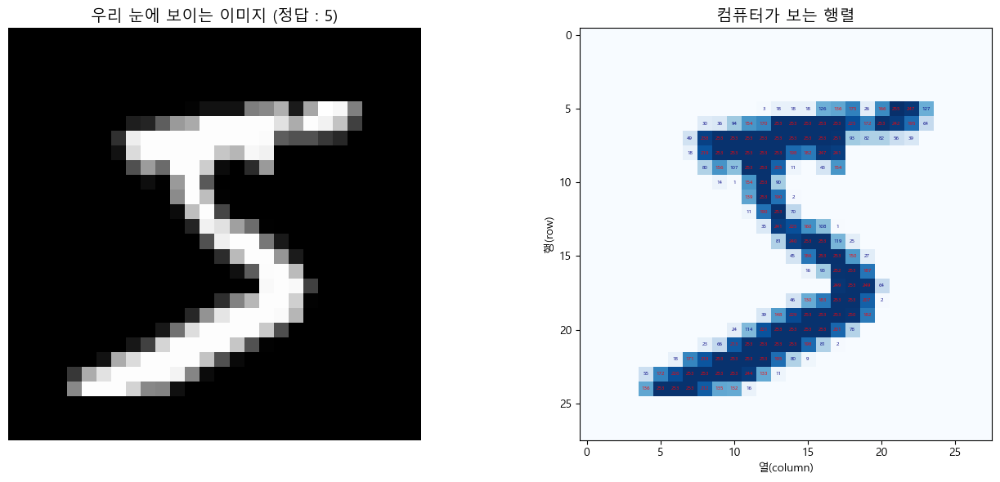

In [8]:
# 훈련 이미지(정답 5) 선택
sample_idx = 0
sample_image = x_train_raw[sample_idx] # shape : (28, 28)
sample_label = y_train_raw[sample_idx] # 정답 숫자 : 5

print(f"이 이미지의 정답 숫자 : {sample_label}")
print(f"이미지 배열 shape : {sample_image.shape} <- 28행 x 28열 행렬!")
print()

# 시각화
# fig : 전체 사이즈
# axes : axes[0] 왼쪽, axes[1] 오른쪽
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽
axes[0].imshow(sample_image, cmap='grey')
axes[0].set_title(f"우리 눈에 보이는 이미지 (정답 : {sample_label})", fontsize=14)
axes[0].axis('off')

# 오른쪽
ax = axes[1]
im = ax.imshow(sample_image, cmap='Blues')

# 각 픽셀에 숫자 표시(28 x 28은 너무 빡빡해서 중앙 14 x 14만 표시)
for row in range(28):
    for col in range(28):
        val = sample_image[row, col]
        if val > 0: #0인 픽셀(배경)은 숫자 생략
            ax.text(col, row, str(val), ha='center', va='center', fontsize=4.5, color='red' if val > 127 else 'navy')
ax.set_title("컴퓨터가 보는 행렬", fontsize=14)
ax.set_xlabel("열(column)")
ax.set_ylabel("행(row)")

plt.tight_layout()
plt.show()

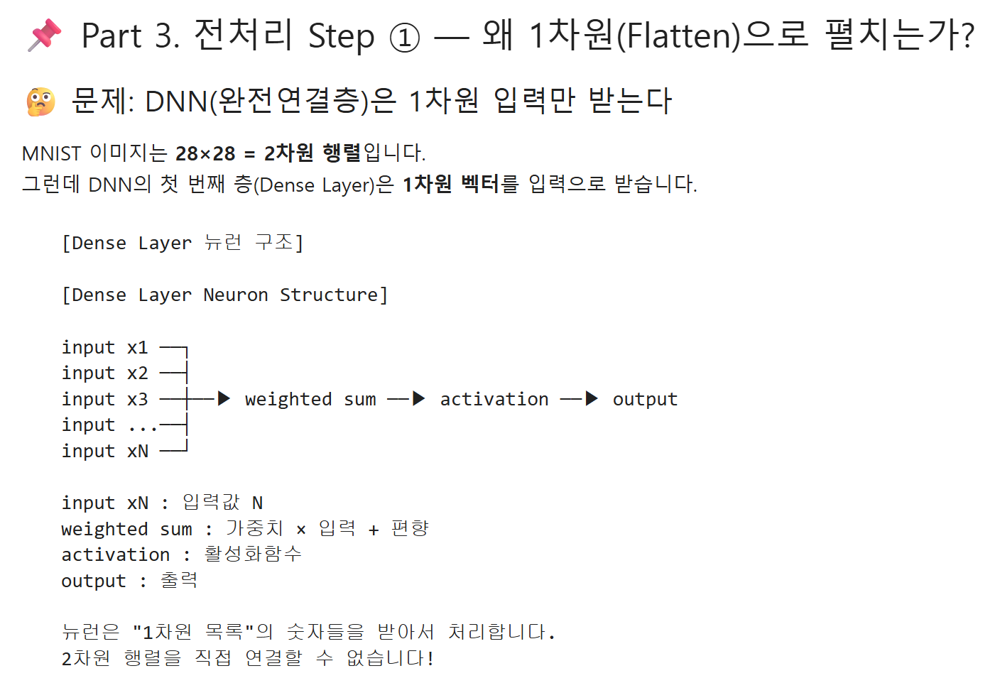

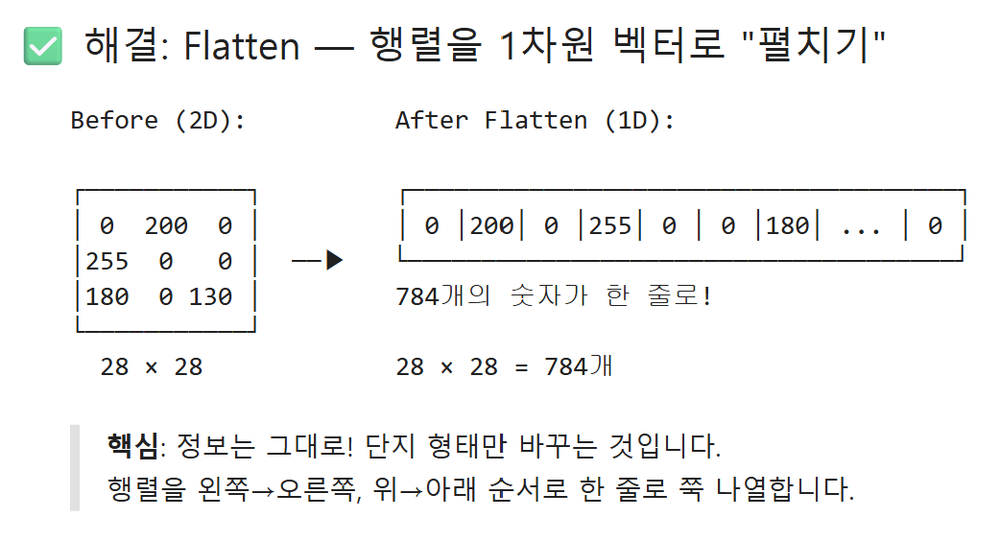

In [ ]:
# Flatten 시각화 : 2차원 -> 1차원으로

In [18]:
# 작은 예시로 먼저
mini_image = np.array([
    [ 0,  50, 200, 255],
    [10,   0, 180,   0],
    [ 0, 230,   0, 120],
    [80,   0, 170,   0]
])
print(f"shape : {mini_image.shape} <-2차원") 
print(mini_image)
print()

# flatten 2D -> 1D
# numpy의 .flatten() 또는 .reshape(-1)로 펼친다
flat_image = mini_image.flatten() # 행 순서대로(위 -> 아래, 좌 -> 우)
print(f"shape: {flat_image.shape}  ← 1차원")
print(flat_image)
print()

# 실제 Mnist에 적용
print("=" * 50)
print("실제 MNIST 이미지 Flatten")
print("=" * 50)
print(f"원본 shape : {x_train_raw[0].shape} <- 28 x 28 행렬")
flat_sample = x_train_raw[0].flatten()
print(f"Flatten 후 : {flat_sample.shape} <- 784개 숫자 한줄")

shape : (4, 4) <-2차원
[[  0  50 200 255]
 [ 10   0 180   0]
 [  0 230   0 120]
 [ 80   0 170   0]]

shape: (16,)  ← 1차원
[  0  50 200 255  10   0 180   0   0 230   0 120  80   0 170   0]

실제 MNIST 이미지 Flatten
원본 shape : (28, 28) <- 28 x 28 행렬
Flatten 후 : (784,) <- 784개 숫자 한줄


In [ ]:
# Flatten 이미지로 확인

In [20]:
print("2차원 이미지 형태")
print("shape:", x_train_raw[0].shape)
print()

for x in x_train_raw[0]:
    for i in x:
        print('%4d' % i, end='')
    print()

2차원 이미지 형태
shape: (28, 28)

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
   0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
   0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
   0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247

In [22]:
print("1차원으로 펼친 형태")

flatten_image = x_train_raw[0].reshape(784)
print("shape:", flatten_image.shape)
print()

for i in flatten_image:
    print('%d ' % i, end='')

1차원으로 펼친 형태
shape: (784,)

0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 18 18 18 126 136 175 26 166 255 247 127 0 0 0 0 0 0 0 0 0 0 0 0 30 36 94 154 170 253 253 253 253 253 225 172 253 242 195 64 0 0 0 0 0 0 0 0 0 0 0 49 238 253 253 253 253 253 253 253 253 251 93 82 82 56 39 0 0 0 0 0 0 0 0 0 0 0 0 18 219 253 253 253 253 253 198 182 247 241 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 80 156 107 253 253 205 11 0 43 154 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 14 1 154 253 90 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 139 253 190 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 11 190 253 70 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 35 241 225 160 108 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 81 240 253 253 119 25 0 0 0 

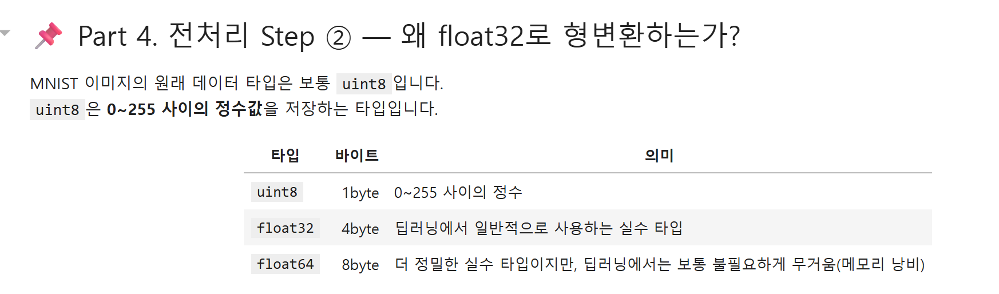

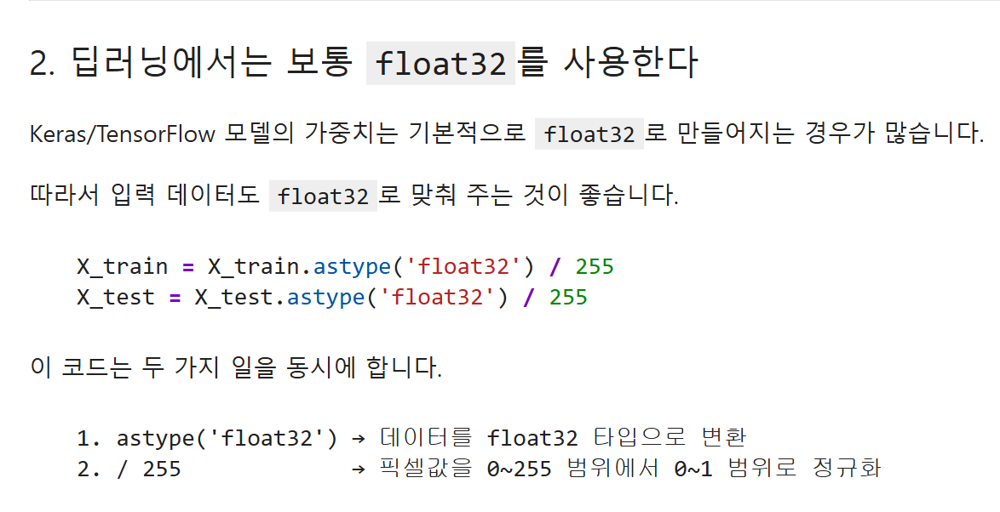

In [ ]:
# 타입 정합성, 메모리 효율, 연산 효율의 이유로 float32를 활용한다.

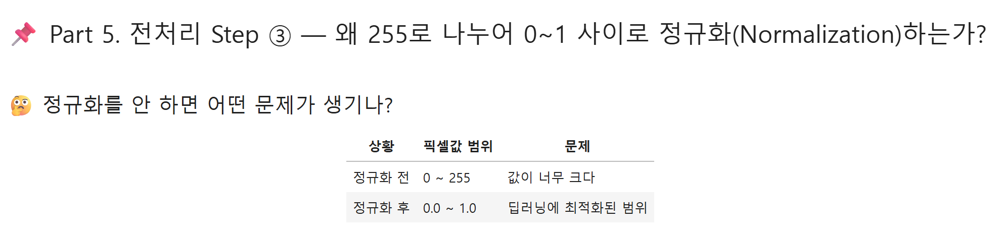

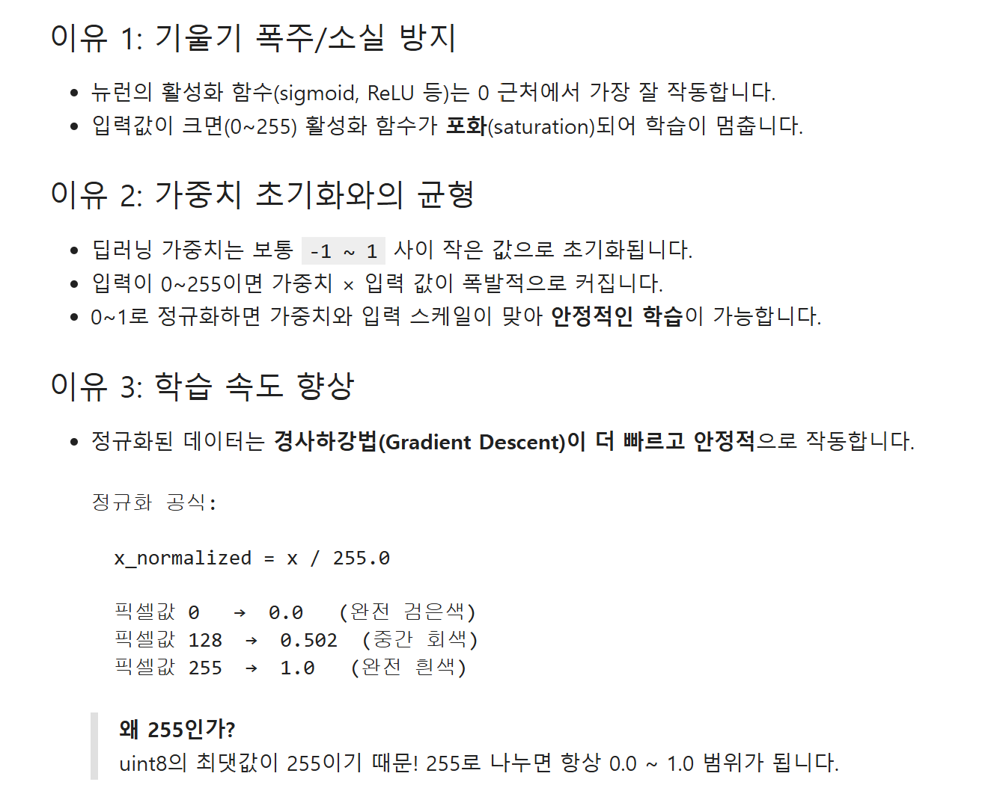

In [ ]:
# 결론!

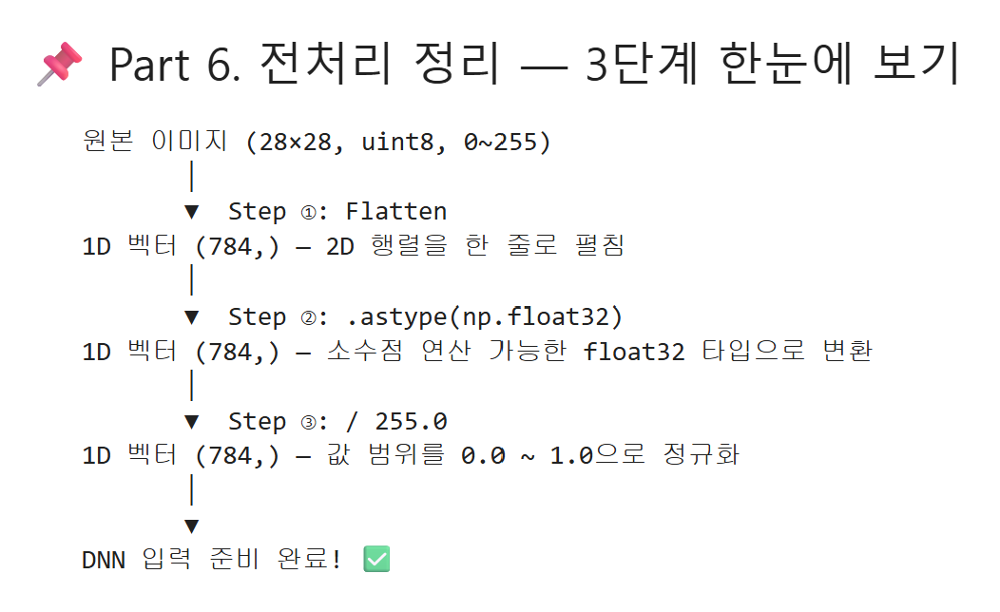

In [ ]:
# 전처리 실제 적용

In [29]:
print("📋 전처리 전 상태")
print(f" x_train shape : {x_train_raw.shape}")
print(f" dtype : {x_train_raw.dtype}")
print(f" 값 범위 : {x_train_raw.min()} ~ {x_train_raw.max()}")
print()

# ─────────────────────────────────────
# Step ①: Flatten — 28×28 → 784
# reshape(샘플수, -1) : -1은 자동 계산
# 60000장 × 28 × 28 → 60000장 × 784
# ─────────────────────────────────────
x_train = x_train_raw.reshape(x_train_raw.shape[0], -1) # (60000, 784)
x_test = x_test_raw.reshape(x_test_raw.shape[0], -1) # (10000, 784)

print("✅ Step ① flatten 완료")
print(f" x_train shape : {x_train.shape} <- (60000, 784)")
print()

# ─────────────────────────────────────
# Step ②: float32 형변환
# ─────────────────────────────────────
x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

print("✅ Step ② float32 변환 완료")
print(f" x_train dtype : {x_train.dtype}")
print(f" x_train dtype : {x_test.dtype}")
print()

# ─────────────────────────────────────
# Step ③: 정규화 — 255.0으로 나누기
# 0~255 → 0.0~1.0
# ─────────────────────────────────────
x_train = x_train / 255.0
x_test = x_test / 255.0

print("✅ Step ③ 정규화 완료")
print(f" 값 범위 : {x_train.min():.1f} ~ {x_train.max():.1f}")
print()

print("=" * 50)
print("📋 전처리 후 최종 상태")
print(f"  x_train shape : {x_train.shape}")
print(f"  dtype         : {x_train.dtype}")
print(f"  값 범위        : {x_train.min():.3f} ~ {x_train.max():.3f}")
print()

# 레이블 확인 (별도 처리 불필요 — keras가 내부에서 처리)
print(f"  y_train (레이블): {y_train_raw[:10]} ... (정수 0~9 그대로 사용)")

📋 전처리 전 상태
 x_train shape : (60000, 28, 28)
 dtype : uint8
 값 범위 : 0 ~ 255

✅ Step ① flatten 완료
 x_train shape : (60000, 784) <- (60000, 784)

✅ Step ② float32 변환 완료
 x_train dtype : float32
 x_train dtype : float32

✅ Step ③ 정규화 완료
 값 범위 : 0.0 ~ 1.0

📋 전처리 후 최종 상태
  x_train shape : (60000, 784)
  dtype         : float32
  값 범위        : 0.000 ~ 1.000

  y_train (레이블): [5 0 4 1 9 2 1 3 1 4] ... (정수 0~9 그대로 사용)


In [ ]:
# ============================================================
# Keras DNN 모델 구축 — model.add() 방식
# ============================================================

In [ ]:
# MNIST 손글씨 숫자 분류 모델

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

#데이터 전처리
X_train = X_train.reshape(X_train.shape[0], -1).astype("float32") / 255
X_test = X_test.reshape(X_test.shape[0], -1).astype("float32") / 255

#정답 데이터 원-핫 인코딩
Y_train = tf.keras.utils.to_categorical(Y_train, 10)
Y_test = tf.keras.utils.to_categorical(Y_test, 10)

#모델 구성
model=Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(512, activation='relu'))
model.add(Dense(10, activation='softmax'))

#모델 컴파일
model.compile(
    loss = 'categorical_crossentropy',
    optimizer='adam',
    metrics=["accuracy"]
)

#모델 저장 및 조기 종료
MODEL_DIR = "./model_mnist_b"

if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath = "./model_mnist_b/{epoch:02d}-{val_loss:.4f}.keras"

checkpointer = ModelCheckpoint(
    filepath=modelpath,
    monitor="val_loss",
    verbose=1,
    save_best_only=True
)

early_stopping_callback = EarlyStopping(
    monitor="val_loss",
    patience=10
)

#모델 학습
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=30,
    batch_size=200,
    verbose=2,
    callbacks=[early_stopping_callback, checkpointer]
)

#테스트 정확도 출력
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"\nTest Accuracy : {test_accuracy:.4f}")

#시각화

#검증 데이터 오차
y_vloss = history.history["val_loss"]

#학습 데이터 오차
y_loss = history.history["loss"]

#x축 -> epoch 횟수
x_len = np.arange(len(y_loss))

plt.plot(x_len, y_vloss, marker=".", color="red", label="Testest Loss")
plt.plot(x_len, y_loss, marker=".", color="blue", label="Trainest Loss")

plt.legend(loc="upper right")
plt.grid()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

#테스트 데이터로 모델 평가
test_loss, test_accuracy = model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

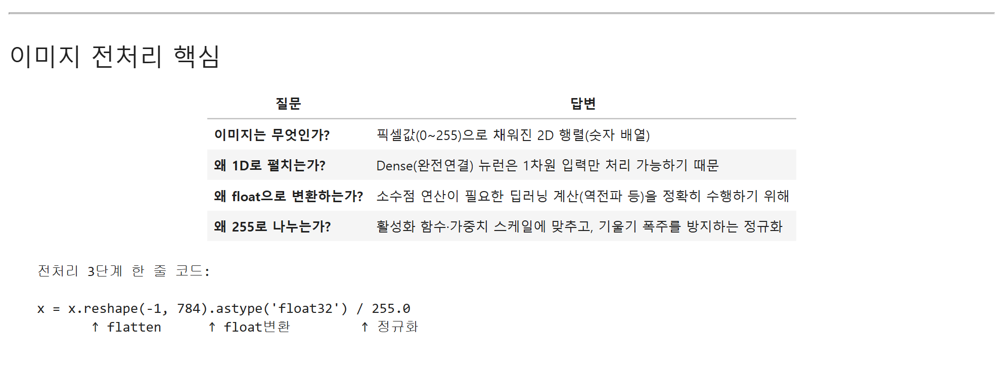

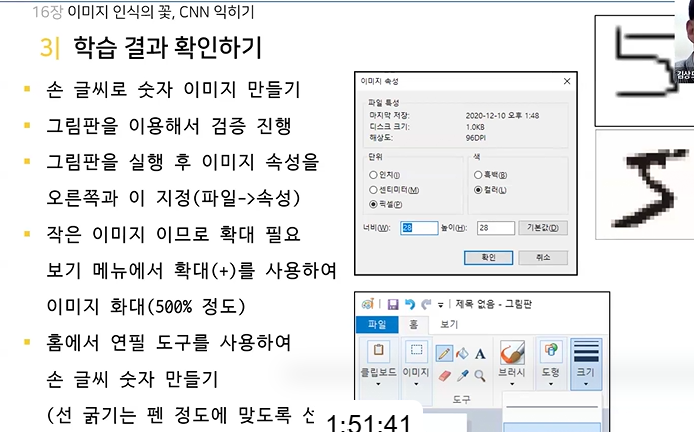

In [ ]:
# pip install opencv-python

In [ ]:
import tensorflow as tf
import sys
import os
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import numpy as np
import cv2 # 굉장히 강력한 이미지 오픈소스

model = load_model('./model/07-0.0610.keras')
model.summary()

test_num1 = cv2.imread('./model/minist_test/3.jpg')
test_num2 = cv2.imread('./model/minist_test/4.jpg')
test_num3 = cv2.imread('./model/minist_test/5.jpg')

test_num1 = cv2.resize(test_num1, (28,28))
test_num2 = cv2.resize(test_num2, (28,28))
test_num3 = cv2.resize(test_num3, (28,28))

#RGB file을 gray로
test_num1 = cv2.cvtColor(test_num1, cv2.COLOR_BGR2GRAY)
test_num2 = cv2.cvtColor(test_num2, cv2.COLOR_BGR2GRAY)
test_num3 = cv2.cvtColor(test_num3, cv2.COLOR_BGR2GRAY)

#색상을 반전, 보통 이미지 : 0 -> 검은색, 255 -> 흰색
#cmap='Greys'
test_num1 = 255 - test_num1
test_num2 = 255 - test_num2
test_num3 = 255 - test_num3

plt.imshow(test_num1, cmap='Greys'); # Greys : 0 -> 흰색, 255 -> 검은색
plt.show()
plt.imshow(test_num2, cmap='Greys');
plt.show()
plt.imshow(test_num3, cmap='Greys');
plt.show()

# 학습할 때와 동일하게 데이터 전처리
test_num1 = test_num1.reshape(1, -1).astype('float64') / 255
test_num2 = test_num2.reshape(1, -1).astype('float64') / 255
test_num3 = test_num3.reshape(1, -1).astype('float64') / 255

test_predict = list()
test_predict.append(model.predict(test_num1))
test_predict.append(model.predict(test_num2))
test_predict.append(model.predict(test_num3))

print('The Answer 3 is', test_predict[0].argmax())
print('The Answer 4 is', test_predict[1].argmax())
print('The Answer 5 is', test_predict[2].argmax())

In [ ]:
# for문으로 간략화

In [ ]:
import tensorflow as tf
import sys
import os
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import numpy as np
import cv2

model = load_model('./model/07-0.0610.keras')
model.summary()

n=3
test_num=[[0]*n for _ in range(n)]
test_num[0] = cv2.imread('./model/minist_test/3.jpg')
test_num[1] = cv2.imread('./model/minist_test/4.jpg')
test_num[2] = cv2.imread('./model/minist_test/5.jpg')

test_predict = list()

for i in range(n):
    test_num[i] = cv2.cvtColor(test_num[i], cv2.COLOR_BGR2GRAY)
    test_num[i] = cv2.resize(test_num[i], (28, 28))
    test_num[i] = 255 - test_num[i]
    plt.imshow(test_num[i], cmap='Greys');
    plt.show()
    test_num[i] = test_num[i].reshape(1, -1).astype('float64') / 255
    test_predict.append(model.predict(test_num[i]))
    print('The Answer', i, 'is', test_predict[i].argmax())

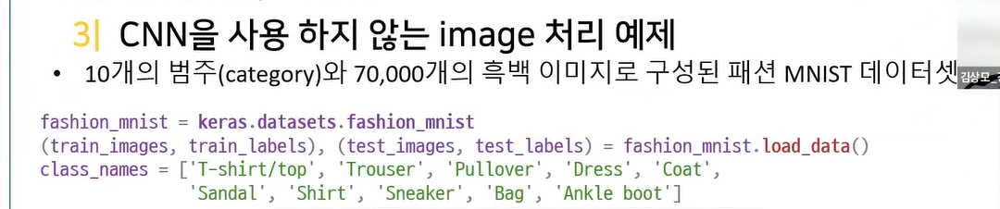

In [ ]:
# mnist 데이터셋은 품질이 좋은 데이터셋이다
# 왜? 이미지가 중앙에 있고, 배경색과 목적인 이미지의 색이 명확히 구분되며, 사람 발 등 목적 외의 이미지가 없기 떄문에.

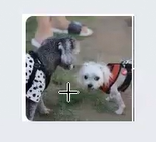

In [17]:
# ============================================================
# MNIST 패션 분류 모델
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os

# seed값 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# mnist 데이터 불러오기
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat'
    , 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
# print("train_images :", train_images.shape, "train_labels :", train_labels.shape)
# print("test_images :", test_images.shape, "test_labels :", test_labels.shape)

# 전처리
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

# 전처리 과정 중 (원-핫 인코딩) : 이 코드 안 쓸시 categorical_crossentropy -> sparse_categorical_crossentropy로 교체
# 출력층과 정답 데이터의 구조를 맞추기 위해.
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)

# 모델
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer="Adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# 콜백
save_dir = "./fashion_dense_model"
os.makedirs(save_dir, exist_ok=True)

checkpoint_path = os.path.join(save_dir, "best.keras") # Keras 저장 형식
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor="val_accuracy", save_best_only=True
    )
]

# 학습
history = model.fit(
    train_images, 
    train_labels,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

# 평가
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"\n[테스트] loss={test_loss:.4f}, acc={test_acc:.4f}")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8184 - loss: 0.5201 - val_accuracy: 0.8497 - val_loss: 0.4155
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8626 - loss: 0.3846 - val_accuracy: 0.8663 - val_loss: 0.3622
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8766 - loss: 0.3411 - val_accuracy: 0.8738 - val_loss: 0.3443
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8861 - loss: 0.3118 - val_accuracy: 0.8770 - val_loss: 0.3348
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8930 - loss: 0.2913 - val_accuracy: 0.8803 - val_loss: 0.3253
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8997 - loss: 0.2753 - val_accuracy: 0.8827 - val_loss: 0.3202
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9056 - loss: 0.2596 - val_accuracy: 0.8837 - val_loss: 0.3186
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9107 - loss: 0.2470 - val_accu

In [ ]:
# 검증

이미지 갯수 : 3
이미지 이름 :  1 2 3


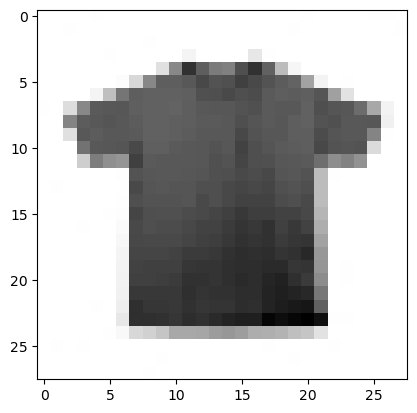

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
T-shirt/top


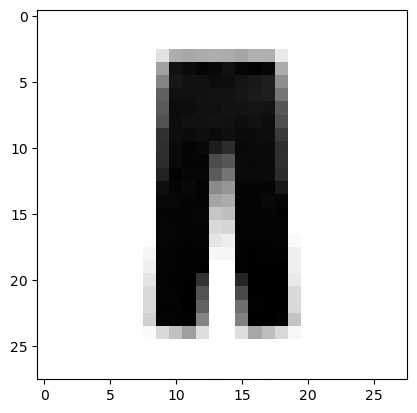

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Trouser


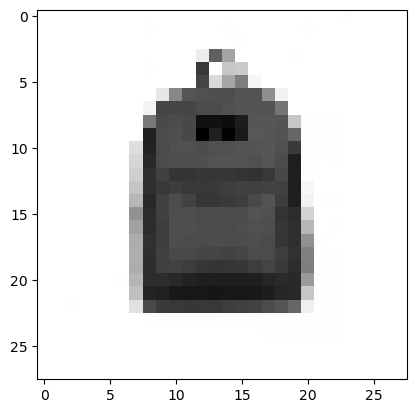

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Bag


In [22]:
import tensorflow as tf
import sys
import os
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np
import cv2

model = load_model('./fashion_dense_model/best.keras')
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat'
    , 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

n = int(input('이미지 갯수 :'))
test_num = [None] * n # 리스트 초기화

# 파일 이름을 정수 리스트 대신 문자열 리스트로 받도록 입력 수정
jpg_list = input('이미지 이름 : ').split()
test_predict = list()

# RGB파일을 cmap='Greys'에 맞게 변환
for i in range(n):
    test_num[i] = cv2.imread('./My_fashion_mnist/' + jpg_list[i] + '.jpg')
    if test_num[i] is None:
        print(f"Error: Image '{jpg_list[i]}.jpg' not found")
        continue
    test_num[i] = cv2.cvtColor(test_num[i], cv2.COLOR_BGR2GRAY)
    test_num[i] = 255 - test_num[i]
    plt.imshow(test_num[i], cmap='Greys')
    plt.show()
    test_num[i] = test_num[i].reshape(1, -1).astype('float32') / 255
    # test_num[i] = test_num[i] / 255
    # test_num[i] = np.expand_dims(test_num[i], 0)
    prediction = model.predict(test_num[i])
    print(class_names[prediction.argmax()])

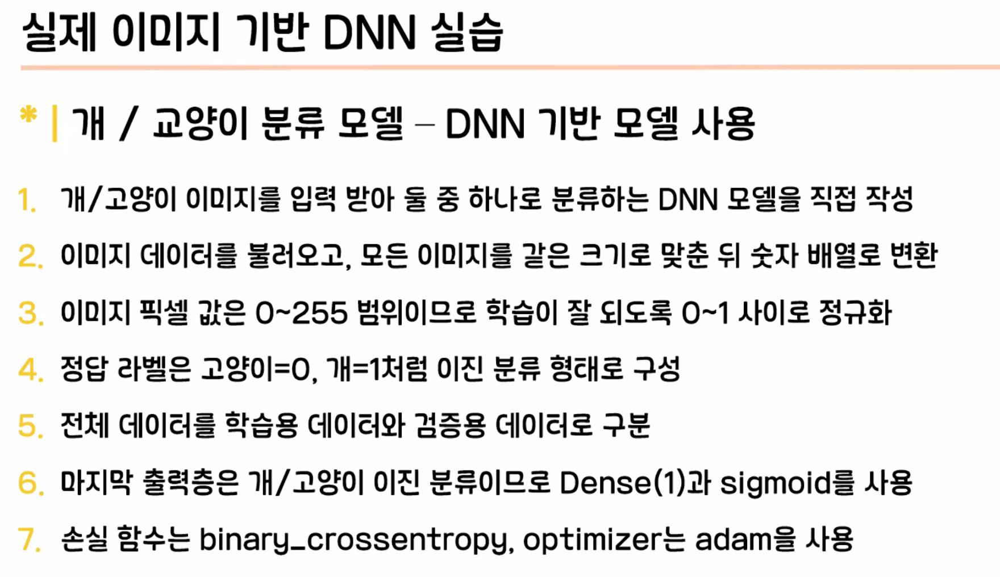

In [6]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 데이터
rootPath = './'
img_dir = os.path.join(rootPath, 'Train')
img_size = (128, 128)

data = []
labels = []

for label, folder in enumerate(['cat', 'dog']): # 0: cat, 1: dog
    folder_path = os.path.join(img_dir, folder)
    for fname in os.listdir(folder_path):
        if fname.endswith('jpg'):
            fpath = os.path.join(folder_path, fname)
            img = load_img(fpath, target_size=img_size) # resize
            img_array = img_to_array(img) / 255.0 # img_to_array : (128, 128, 3) + 정규화
            data.append(img_array)
            labels.append(label)
# print("data type(변환 전):", type(data))
# print("data shape(변환 전):", data[0].shape)

# 넘파이 배열 변환
X = np.array(data)
y = np.array(labels)
# print("data type(변환 후):", type(X))
# print("data shape(변환 후):", X.shape)

# 입력을 DNN에 맞도록 1차원으로 reshpae
X = X.reshpae(X.reshpae[0], -1) # 샘플 수 (128 * 128 * 3)

# 훈련/검증 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# DNN모델 구성
model = Sequential()
model.add(Input(shape=(128*128*3,)))
model.add(layers.Dense(512, activation='relu'))
# model.add(layers.Dropout(0.5))
model.add(layers.Dense(256, activation='relu'))
# model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

# 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 콜백 설정
checkpointer = ModelCheckpoint(filepath="Model_DNN_NoGen.keras", monitor='val_loss', verbose=1, seve_best_only=True)
early_stop = EarlyStopping(patience=5, restore_best_weigths=True)

# 학습
history = model.fit(X_train, y_train, epochs=32, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stop, checkpointer])

data type(변환 전): <class 'list'>
data shape(변환 전): (128, 128, 3)
data type(변환 후): <class 'numpy.ndarray'>
data shape(변환 후): (2000, 128, 128, 3)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing import image

# 모델 로드
model = load_model("Model_DNN_NoGen.keras")
print(f"모델 로드 완료 : Model_DNN_NoGen.keras")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

cls_index = ['고양이', '개']
test_num = []
rootPath = './Test'

# 고양이 이미지 불러오기
cat_folder = os.path.join(rootPath, 'cat')
for fname in os.listdir(cat_folder):
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(cat_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128)) # 검증할 떄의 모델 사이즈 = 학습할 때의 모델 사이즈
        test_num.append((img, 0)) # 0(label) : 고양이(img)

# 개 이미지 불러오기
dog_folder = os.path.join(rootPath, 'dog')
for fname in os.listdir(dog_folder):
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(dog_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128)) # 검증할 떄의 모델 사이즈 = 학습할 때의 모델 사이즈
        test_num.append((img, 1)) # 1(label) : 개(img)

#예측 및 정확도 계산
correct = 0
cols = 3

for idx in range(0, len(test_num), cols): # (시작, 끝, 건너 뜀)
    batch = test_num[idx:idx + cols] # 시작:끝 (한번에 3개씩 가져옴)
    fig, axes = plt.subplots(1, len(batch), figsize=(15, 5)) # axes[i] 형태
    if len(batch) == 1: #하나만 남을경우 
        axes = [axes]

    for i, (img, true_label) in enumerate(batch):
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0
        img_array = img_array.reshape(1, -1)

        result = model.predict(img_array)[0][0]
        pred_label = 1 if result >= 0.5 else 0
        pred_name = '개' if pred_label == 1 else '고양이'
        prob = result if pred_label == 1 else 1-result
        true_name = '고양이' if true_label == 0 else '개'

        #정확도 집계
        is_correct = (pred_label == true_label)
        if is_correct:
            correct += 1

        #이미지 출력
        axes[i].imshow(img)
        axes[i].axis('off')
        title_color = 'black' if is_correct else 'red'
        axes[i].set_title(f"실제 : {true_name}\n 예측 : {pred_name} ({prob:.4f}", fontsize=12, color=title_color)
    
    plt.tight_layout()
    plt.show()
    
#전체 정확도 출력
accuracy = correct / len(test_num) * 100
print(f"\n 전체 정확도 : {correct}/{len(test_num)} = {accuracy:.2f}")

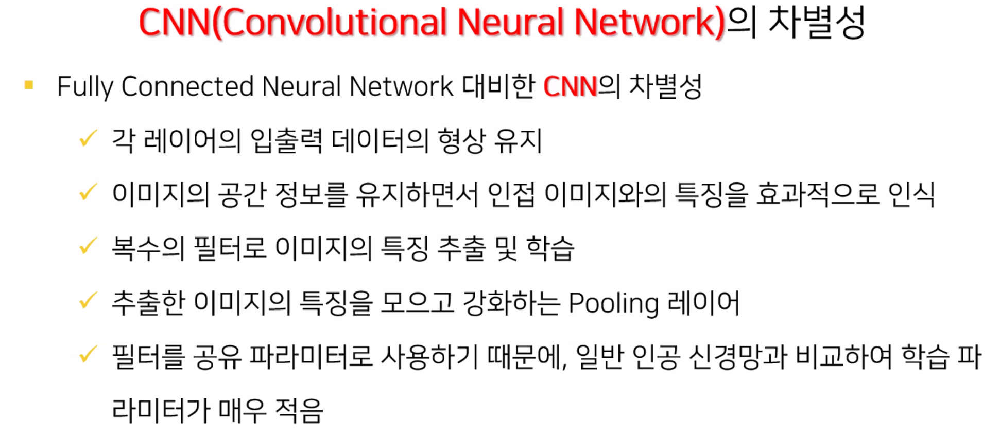

In [ ]:
# CNN은 사람의 시각 인지 과정을 모방한 구조를 가진다.
# 기존 Dense기반 모델 -> Convloution layer 모델로 변경
# 평탄화 X, 2차원 공간에서 특성을 분류한다.
# Convolution(합성곱)

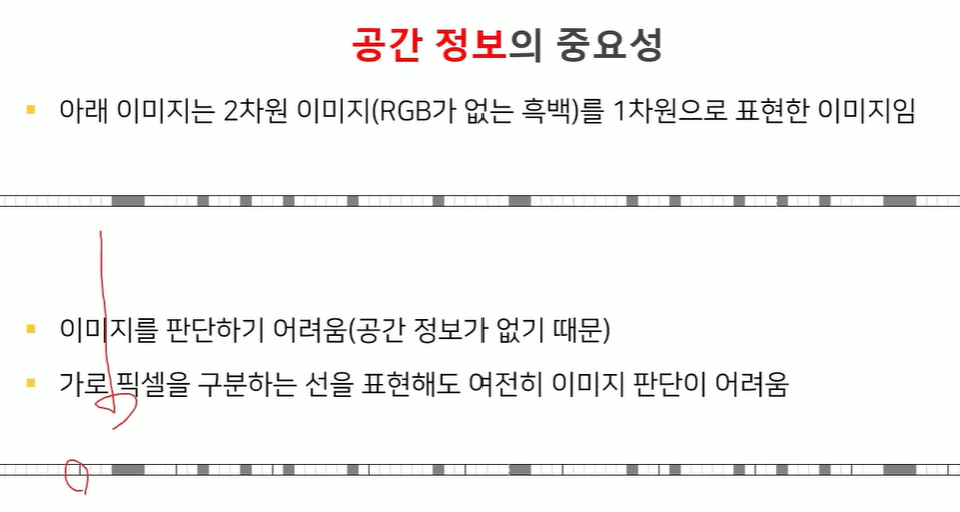

In [ ]:
# 기존 Dense기반 모델 -> Flatten(평탄화) 사용 시 '공간'에 대한 정보가 소실된다.

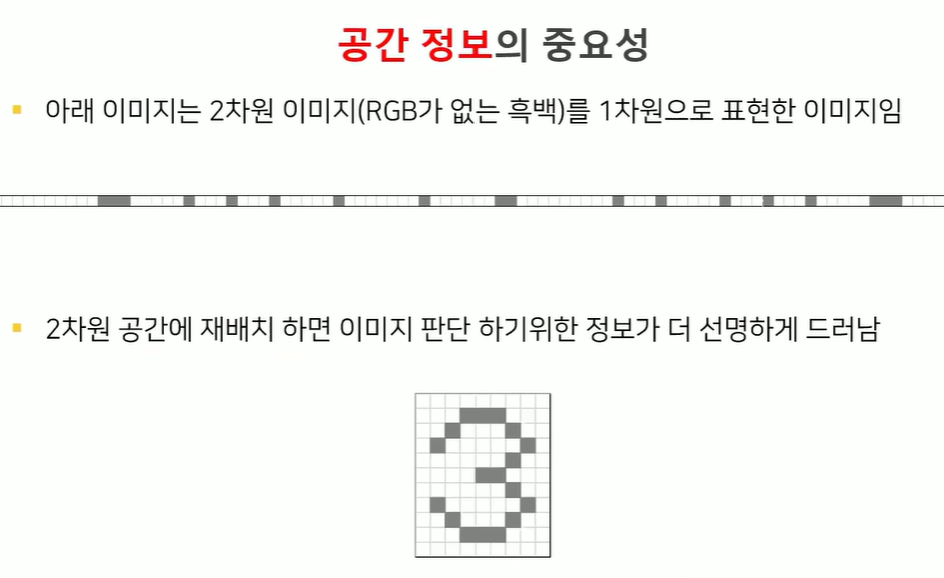

In [ ]:
# Convolution 신경망 동작원리

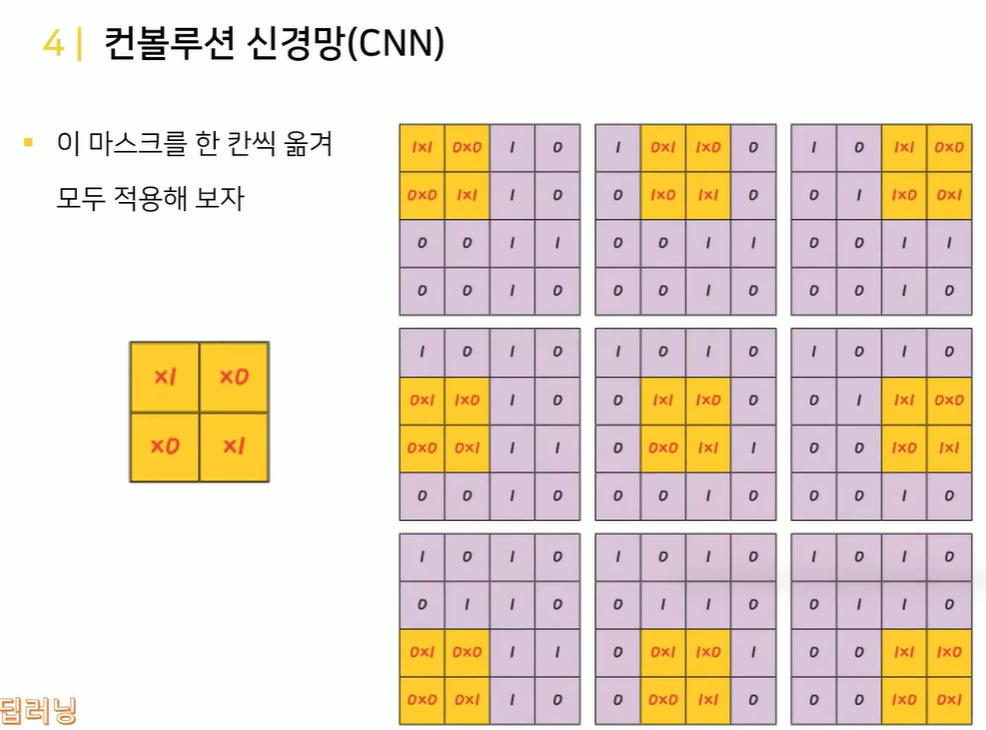

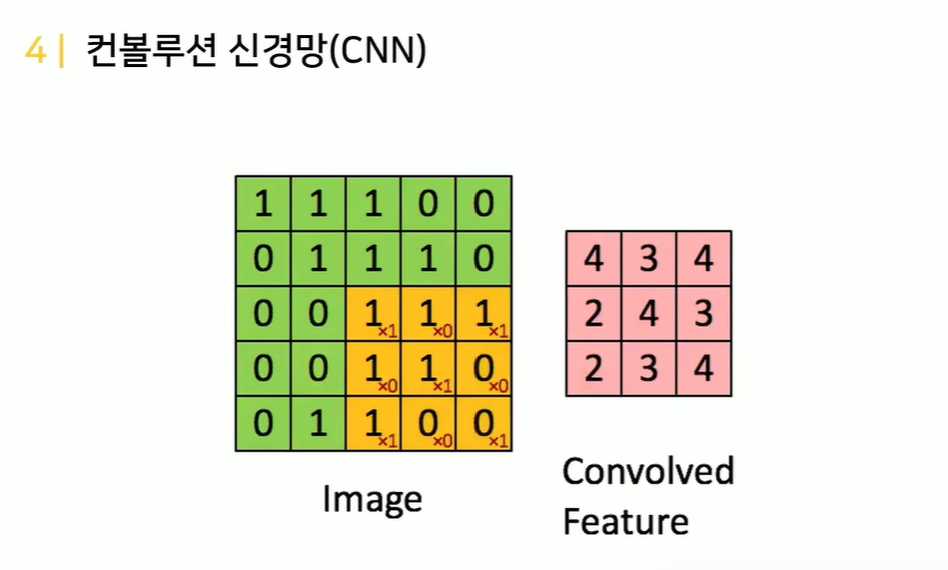

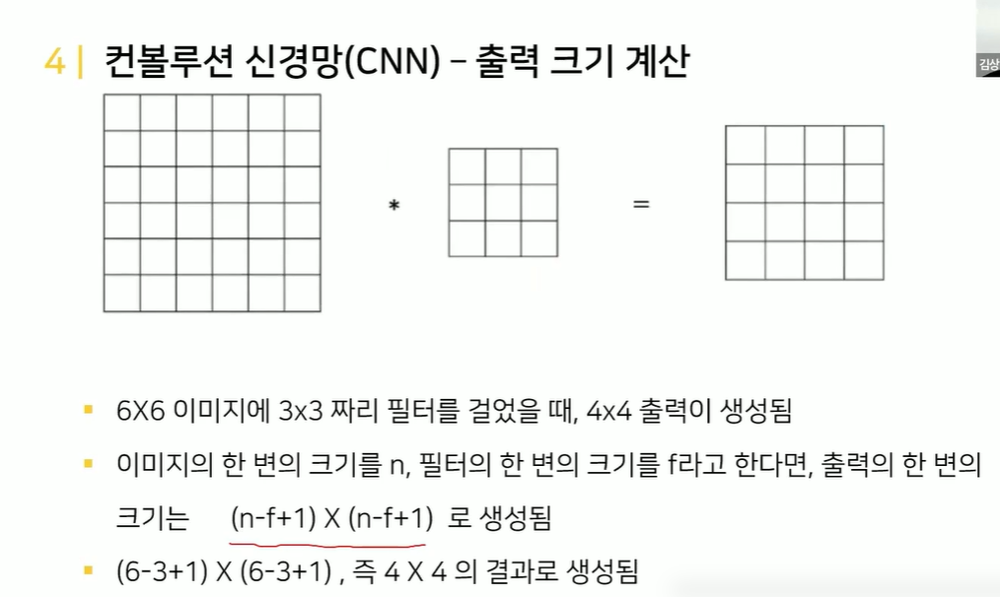

In [ ]:
# 흑백 이미지

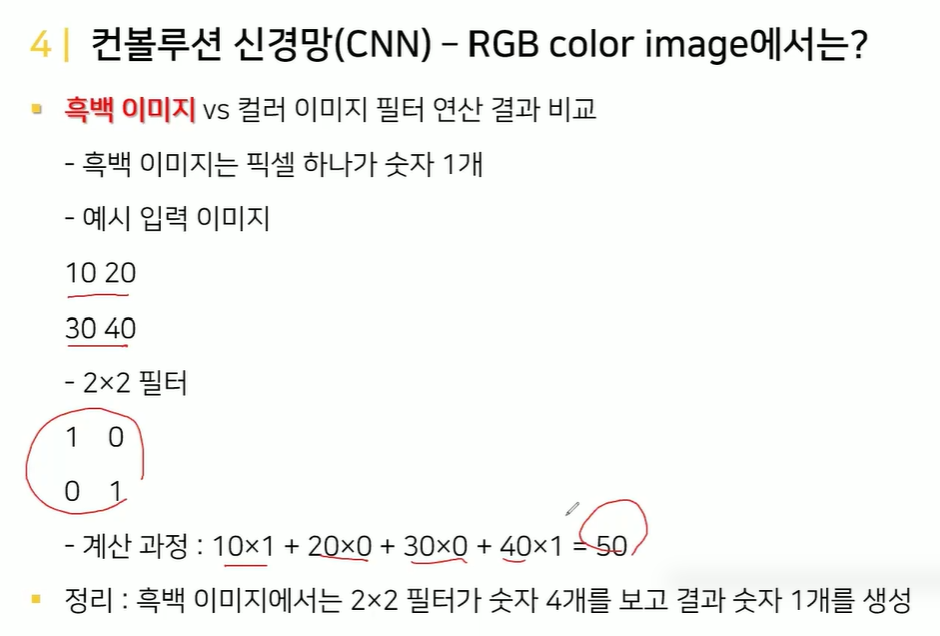

In [ ]:
# 컬러 이미지

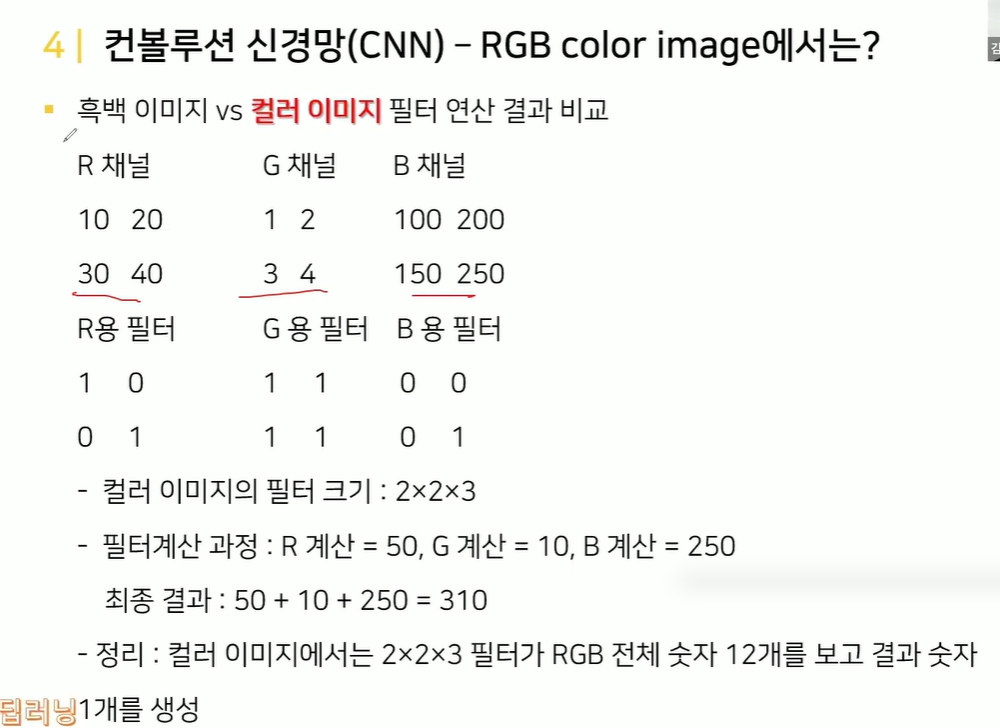

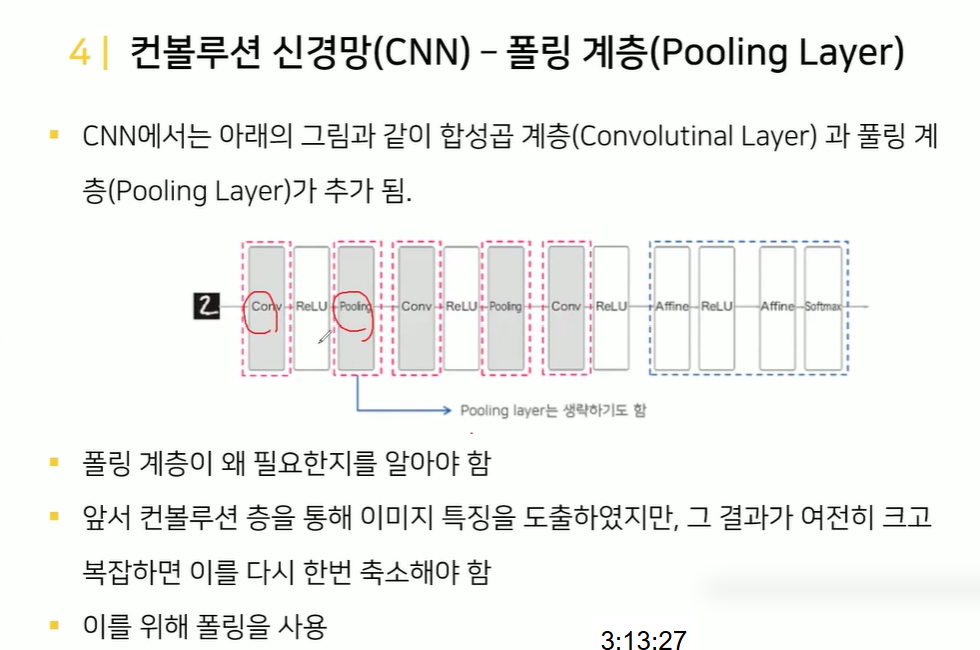

In [ ]:
# 이미지들의 데이터는 연산량이 크기 때문에 '축소'해야햔다.
# 맥스 풀링(max pooling) : 정해진 구역 안에서 '최대값'을 뽑아내는 것
# 평균 풀링(average pooling) : 평균값을 뽑아내는 것

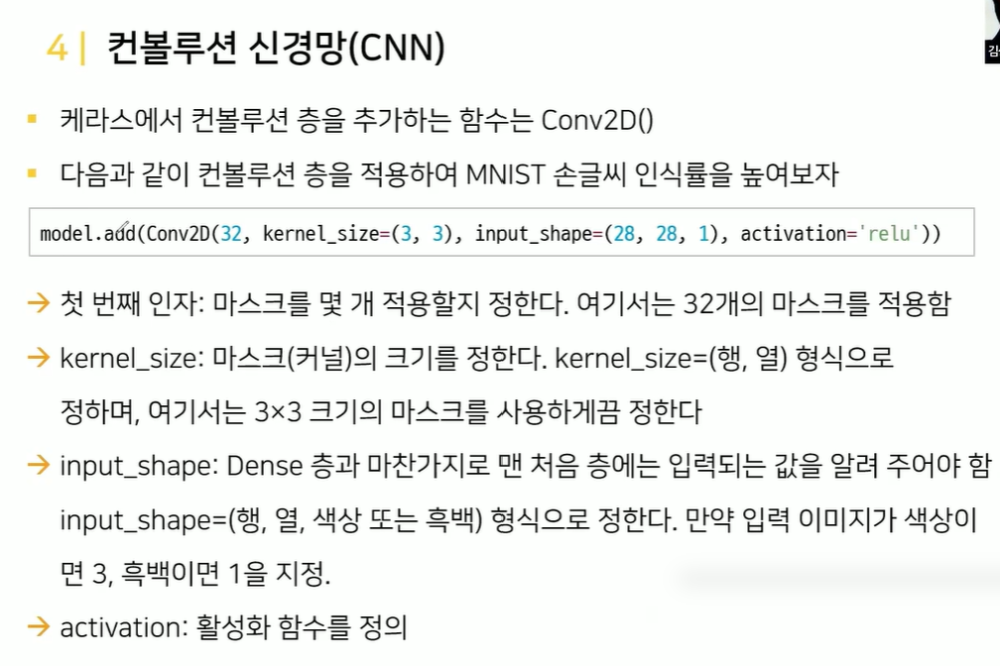

In [ ]:
# model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1), activation='relu'))
# 32 : 몇 개의 마스크(필터) 적용할 지
# kernel_size : 어느정도 크기의 마스크(필터) 적용할 지
# input_shape(행, 열, 색상 또는 흑백)

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

# 시드 고정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 데이터 불러오기
(X_train, Y_train), (X_test, Y_test) = mnist.load_data() # mnist : (학습용 이미지, 학습용 정답), (테스트용 이미지, 테스트용 정답)

# input_shape = (행, 열, 색상(3) 또는 흑백(1))
# CNN에서는 1차원으로 펼치지(DNN) 않고, 이미지 '공간 정보'를 2차원으로 살린다.
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255
Y_train = tf.keras.utils.to_categorical(Y_train)
Y_test = tf.keras.utils.to_categorical(Y_test)

# 컨볼루션 신경망 설정
model = Sequential()
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=2)) 
model.add(Dropout(0.25)) # 학습 중 전체의 25%를 끈다.(과적합 방지)
model.add(Flatten()) # 공간 정보 추출 후, 이를 Dense로 전달하기 위해 평탄화
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 최적화 설정
MODEL_DIR = './model_CNN_M'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

modelpath = "./model_CNN_M/{epoch:02d}-{val_loss:.4f}.keras"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델 실행
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=30, batch_size=200, verbose=0, callbacks = [early_stopping_callback, checkpointer])

# 테스트 정확도 출력
print("\n Test Accuracy : %.4f" % (model.evaluate(X_test, Y_test)[1]))

# 시각화
y_vloss = history.history['val_loss'] # val_loss : 테스트셋 오차
y_loss = history.history['loss'] # loss : 학습셋 오차

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label="Testset_loss")
plt.plot(x_len, y_loss, marker='.', c="blue", label="Trainset_loss")

plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

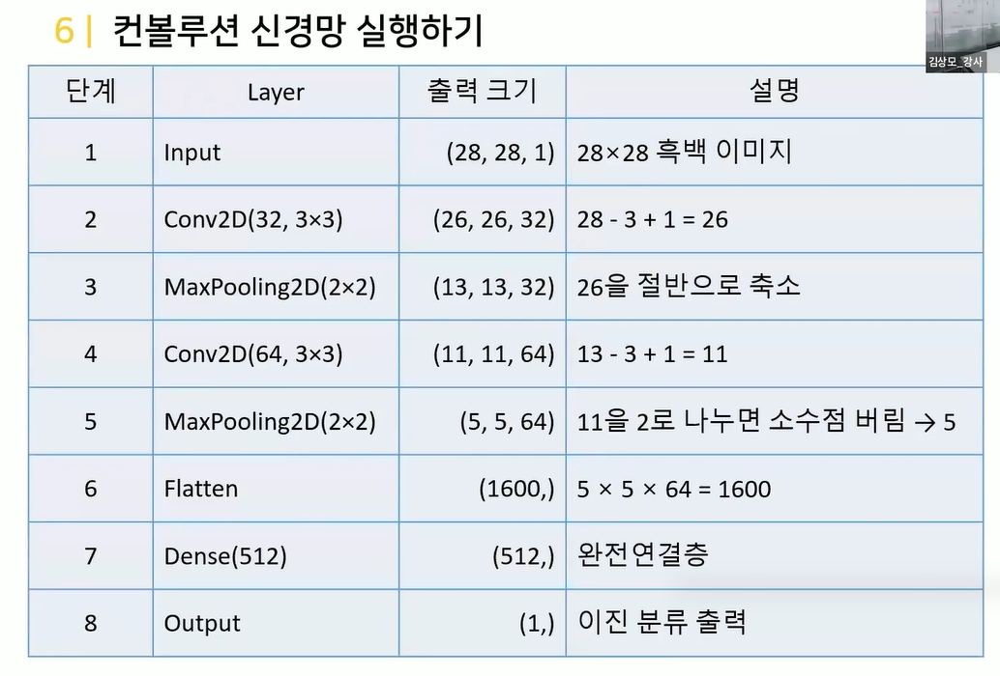

In [ ]:
# 28 x 28 : 이미지
# n(이미지 한 변) = 28
# 3 x 3 : 필터
# f(필터) = 3

# -> (n - f + 1) x (n - f + 1)
# -> (28 -3 + 1) x (28 -3 + 1)
# -> 26, 26, 32

In [ ]:
# 새로운 숫자를 가지고 CNN검증

In [ ]:
import tensorflow as tf
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

from tensorflow.keras.models import load_model

model = load_model('./model/my_model_cnn_use/07-0.0286.keras')
model.summary()

n = 5
test_num = [[0]*n for _ in range(n)]
test_num[0] = cv2.imread('./model/minist_test/3.jpg')
test_num[1] = cv2.imread('./model/minist_test/4.jpg')
test_num[2] = cv2.imread('./model/minist_test/5.jpg')
test_num[3] = cv2.imread('./model/minist_test/7.jpg')
test_num[4] = cv2.imread('./model/minist_test/9.jpg')

#COLOR_BGR2GRAY : RGB -> Greys, 검정바탕에 하얀글씨
#bitwise_not : 하얀바탕에 검정글씨
for i in range(5):
    test_num[i] = cv2.cvtColor(test_num[i], cv2.COLOR_BGR2GRAY)
    test_num[i] = cv2.bitwise_not(test_num[i])
    plt.imshow(test_num[i], cmap='Greys')
    plt.show()
    test_num[i]=test_num[i].reshape(1, 28, 28, 1).astype('float32') / 255 # (데이터 갯수, 세로 크기, 가로 크기, 컬러 or 흑백)
    print('The Answer', i, 'is', model.predict(test_num[i]).argmax())

In [ ]:
# 인식 못한 숫자 확인해보기

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,599,648 (13.73 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,399,766 (9.15 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


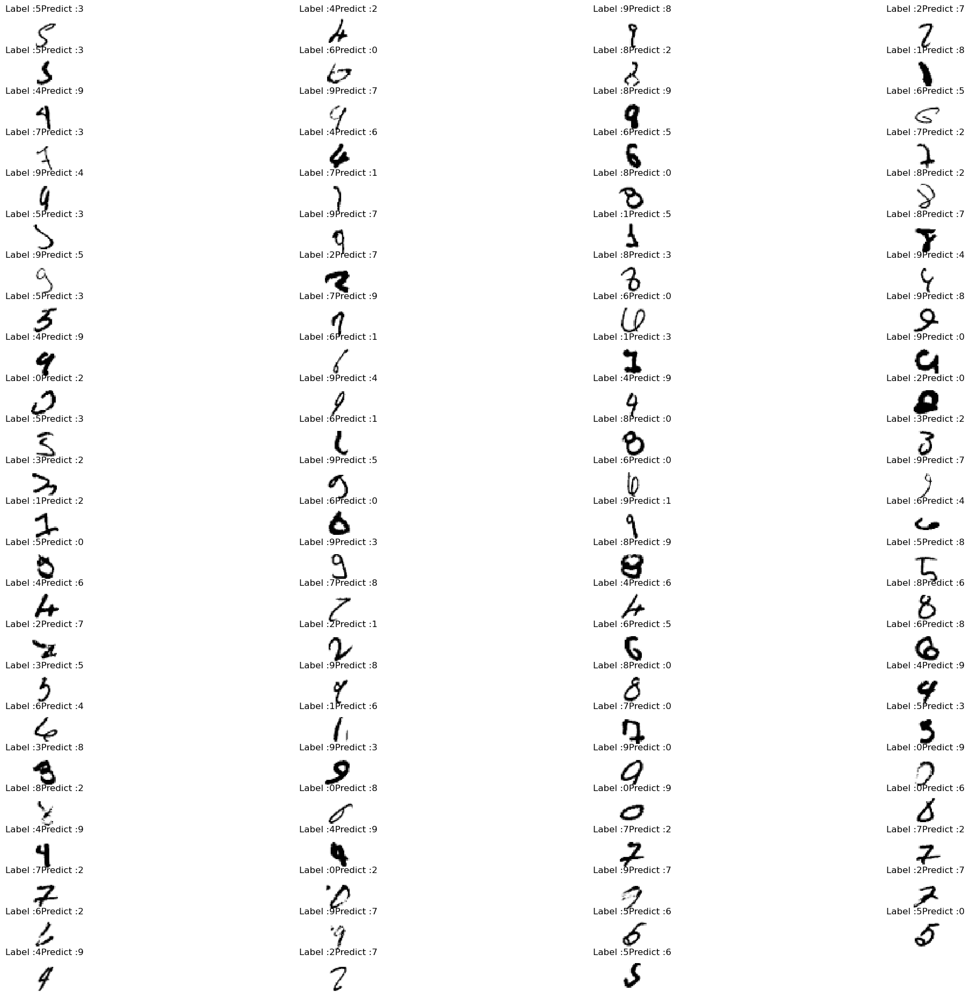

In [5]:
import tensorflow as tf
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import mnist

# 데이터를 읽어온 후 학습시와 동일하게 format을 변경
(X_train, Y_class_train), (X_test, Y_class_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

model = load_model('./model/my_model_cnn_use/07-0.0286.keras')
model.summary()

wrong_result = []
predicted_result = model.predict(X_test)
predicted_labels = np.argmax(predicted_result, axis=1)

for n in range(0, len(Y_class_test)):
    if predicted_labels[n] != Y_class_test[n]:
        wrong_result.append(n)
len(wrong_result)

# 시각화
plt.figure(figsize=(14, 12))

for idx, n in enumerate(wrong_result):
    # 한 줄에 4개씩 표시
    # len(wrong_result) : 홀수일 경우 나머지 대비 -> +1
    # subplot(행, 열, 순서)
    plt.subplot(len(wrong_result)//4+1, 4, idx+1)
    plt.subplots_adjust(left=0.0, bottom=0.0, right=1.5, top=1.52)
    # 28, 28 -> 다시 2차원, 그래프 표시를 위해
    plt.imshow(X_test[n].reshape(28, 28), cmap='Greys', interpolation='nearest')
    plt.title('Label :' + str(Y_class_test[n]) + 'Predict :' + str(predicted_labels[n]))
    plt.axis('off')

plt.show()

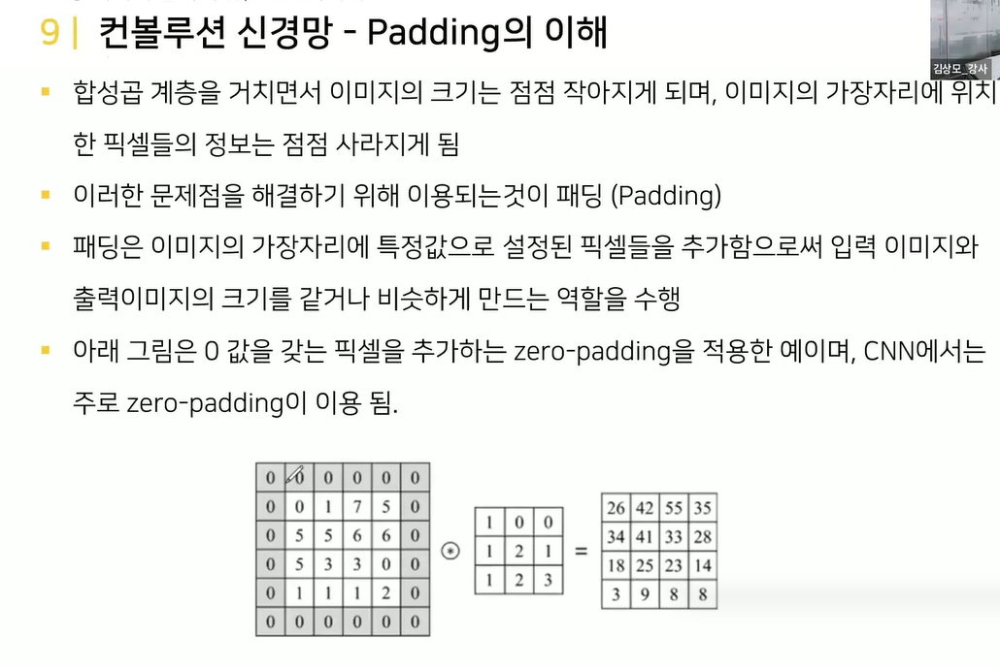

In [ ]:
# 외곽 정보의 소실을 패딩(Padding)으로 보완한다.
# 입력과 출력을 똑같은 크기로 유지하고 싶을 때
# P = F-1/2
# 패딩 두께는 필터 크기(F)에 의해 결정된다.
# 3 X 3 필터 사용 시, P = 3-1 / 2 -> 외곽에 1줄 추가
# 5 X 5 필터 사용 시, P = 5-1 / 2 -> 외곽에 2줄 추가
# 7 X 7 필터 사용 시, P = 7-1 / 2 -> 외곽에 3줄 추가

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D

# 컨볼루션 신경망 설정
model = Sequential()
model.add(Input(shape=(28, 28, 1)))

# Zero-padding : Conv2D 레이어에서 padding='same'을 설정하여 Zero-padding을 적용한다
# padding='same' : 입력과 출력의 크기를 동일하게 유지
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))

# Maxpooling과 Dropout 레이어
model.add(MaxPooling2D(pool_size=2)) 
model.add(Dropout(0.25)) # 학습 중 전체의 25%를 끈다.(과적합 방지)

# Flatten 레이어
model.add(Flatten()) # 공간 정보 추출 후, 이를 Dense로 전달하기 위해 평탄화

# Fully Connected 레이어 + Dropout
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# 출력 레이어
model.add(Dense(10, activation='softmax'))
model.summary()

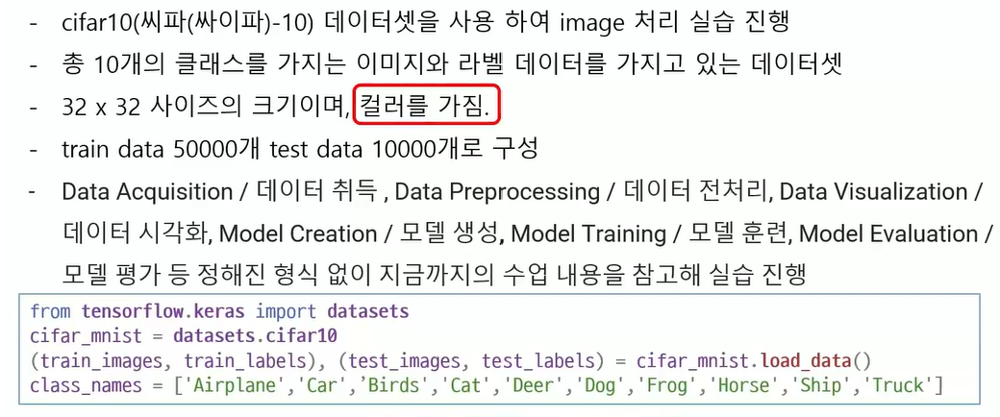

train_images shape : (50000, 32, 32, 3)
train_labels shape : (50000, 1)


C:\Users\wodnr7301\AppData\Local\Temp\ipykernel_10548\1904819374.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel(class_names[int(train_labels[i])]) #train_labels[0]은 nd_array이므로 정수 변환


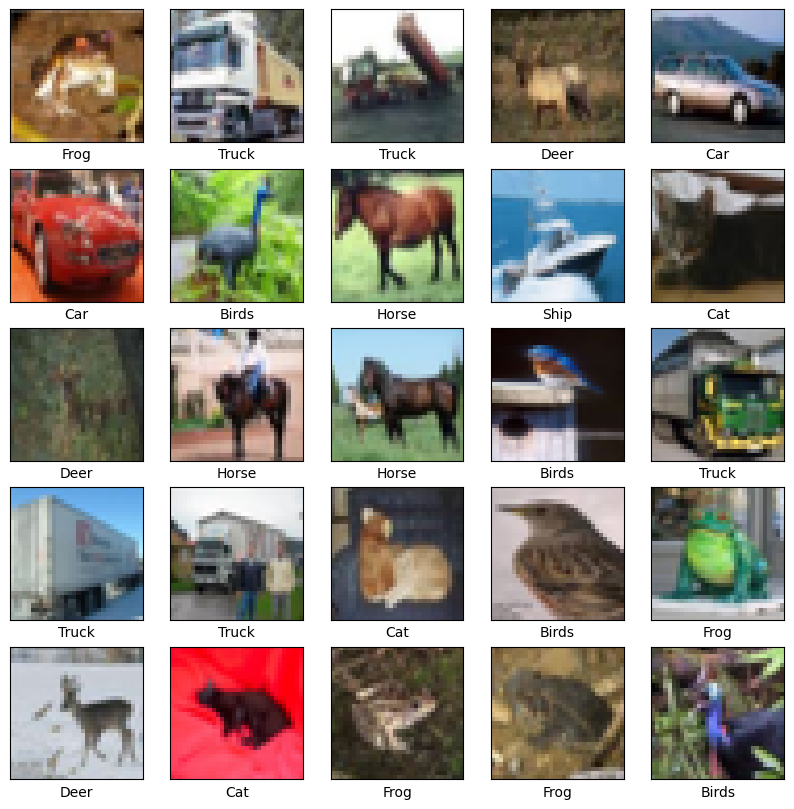

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,546 (1.29 MB)

 Trainable params: 337,546 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.4063 - loss: 1.6270 - val_accuracy: 0.5408 - val_loss: 1.2717
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.5395 - loss: 1.2870 - val_accuracy: 0.6155 - val_loss: 1.0897
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5860 - loss: 1.1588 - val_accuracy: 0.6515 - val_loss: 0.9911
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6142 - loss: 1.0824 - val_accuracy: 0.6714 - val_loss: 0.9448
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6369 - loss: 1.0284 - val_accuracy: 0.6858 - val_loss: 0.9059
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.6564 - loss: 0.9742 - val_accuracy: 0.6859 - val_loss: 0.8969
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6677 - loss: 0.9445 - val_accuracy: 0.6951 - val_loss: 0.8778
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6801 -

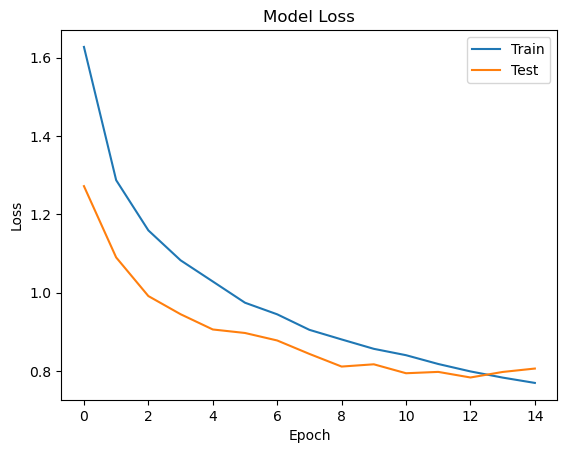

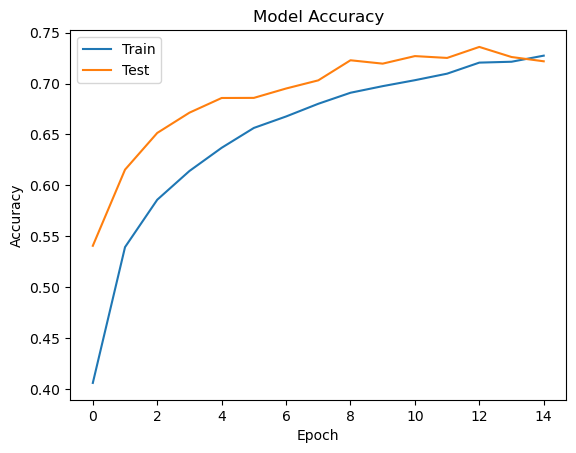

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


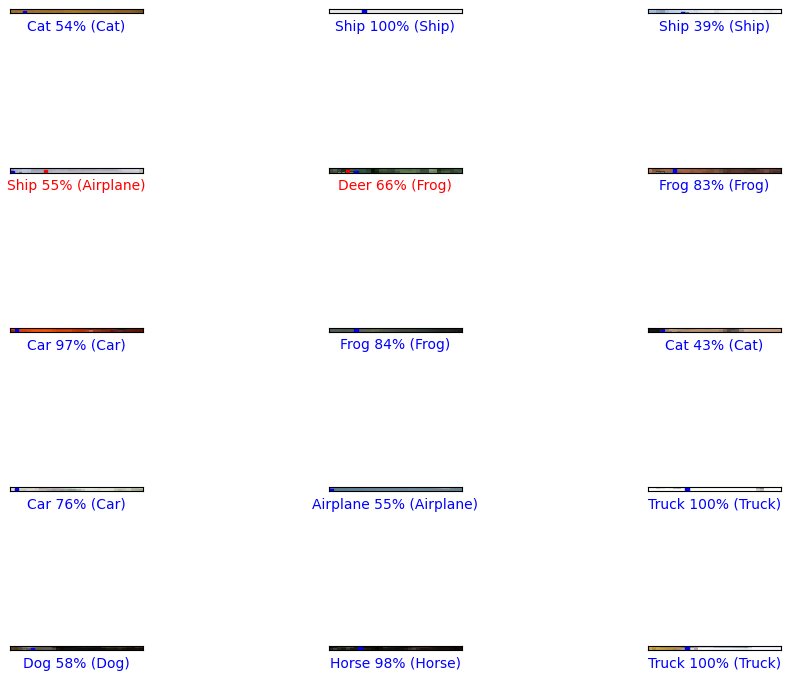

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import utils
from tensorflow.keras import layers
from tensorflow.keras import datasets
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

# 데이터 불러오기
from tensorflow.keras import datasets
cifar_mnist = datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar_mnist.load_data()
class_names = ['Airplane', 'Car', 'Birds', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
print('train_images shape :', train_images.shape)  # 훈련 데이터의 크기
print('train_labels shape :', train_labels.shape)  # 훈련 데이터 라벨의 크기

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1) #행, 열, 갯수
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[int(train_labels[i])]) #train_labels[0]은 nd_array이므로 정수 변환
plt.show()

# 클래스
num_classes = 10

# 정규화
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# 원-핫 인코딩
train_labels = utils.to_categorical(train_labels, num_classes)
test_labels = utils.to_categorical(test_labels, num_classes)

# 모델링
model = keras.Sequential([
    keras.Input(shape=train_images.shape[1:]), # (50000, 32, 32, 3) -> (32, 32, 3)
    Conv2D(32, kernel_size=(3, 3), padding='same', activation=tf.nn.relu),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Conv2D(64, kernel_size=(6, 6), padding='same', activation=tf.nn.relu),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(64, activation=tf.nn.relu),
    Dropout(0.25),
    Dense(num_classes, activation=tf.nn.softmax)
])
model.summary()
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
epochs = 15
batch_size = 64

# 최적화
model_checkpoint = ModelCheckpoint(filepath='best_model_cifar_cnn.keras', monitor='val_loss', save_best_only=True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# 학습
history = model.fit(
    train_images,
    train_labels,
    epochs=epochs,
    validation_data=(test_images, test_labels),
    shuffle=True,
    callbacks=[early_stopping, model_checkpoint]
)

# 평가
loss, acc = model.evaluate(test_images, test_labels)
print("\nLoss : {}, Acc : {}".format(loss, acc))

# 시각화
def plt_show_loss(history):
    plt.plot(history.history['loss']) # Train
    plt.plot(history.history['val_loss']) # Test
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc=0)

def plt_show_acc(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc=0)

plt_show_loss(history)
plt.show()
plt_show_acc(history)
plt.show()

# 예측
predictions = model.predict(test_images)

# 시각화
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == np.argmax(true_label):
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
        100*np.max(predictions_array),
        class_names[np.argmax(true_label)]),
        color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[np.argmax(true_label)].set_color('blue')

num_rows = 5
num_cols = 3
num_images = num_rows * num_cols # 보여주려는 이미지 개수(15)

plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_value_array(i, predictions, test_labels)

plt.show()

In [ ]:
# 새 이미지 파일로 검증

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


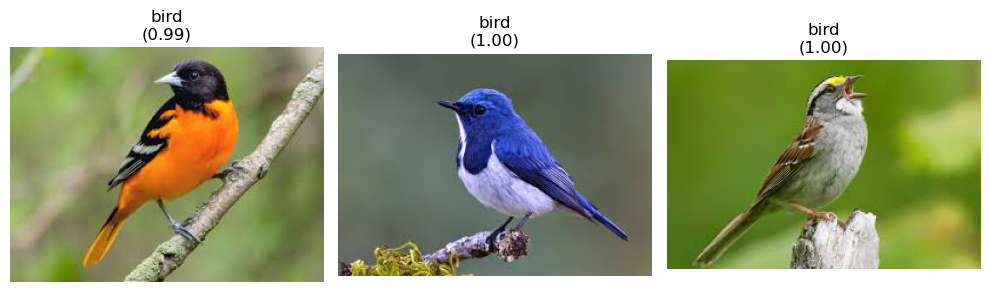

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from PIL import Image

# CIFAR-10 클래스 이름
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog',
               'horse', 'ship', 'truck']

# 모델 불러오기
model = load_model('best_model_cifar_cnn.keras',
                      custom_objects={"softmax_v2": tf.nn.softmax})

# 예측할 이미지 리스트
image_files = ['birds1.jfif', 'birds2.jfif', 'birds3.jfif']

# 예측 함수 정의
def predict_image(img_path):
    img = Image.open(img_path).resize((32, 32))
    if img.mode != 'RGB':
        img = img.convert('RGB')
        
    img_array = image.img_to_array(img) / 255.0 # 정규화
    img_array = np.expand_dims(img_array, axis=0) # (1, 32, 32, 3) - reshape

    pred = model.predict(img_array)
    pred_label = class_names[np.argmax(pred)]
    confidence = np.max(pred)
    return pred_label, confidence

# 이미지 출력 및 예측 결과 표시
plt.figure(figsize=(10, 3))
for i, img_file in enumerate(image_files):
    img_path = f'./c_image/{img_file}'
    pred_label, confidence = predict_image(img_path)
    img = Image.open(img_path)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f'{pred_label}\n({confidence:.2f})')
    plt.axis('off')

plt.tight_layout()
plt.show()

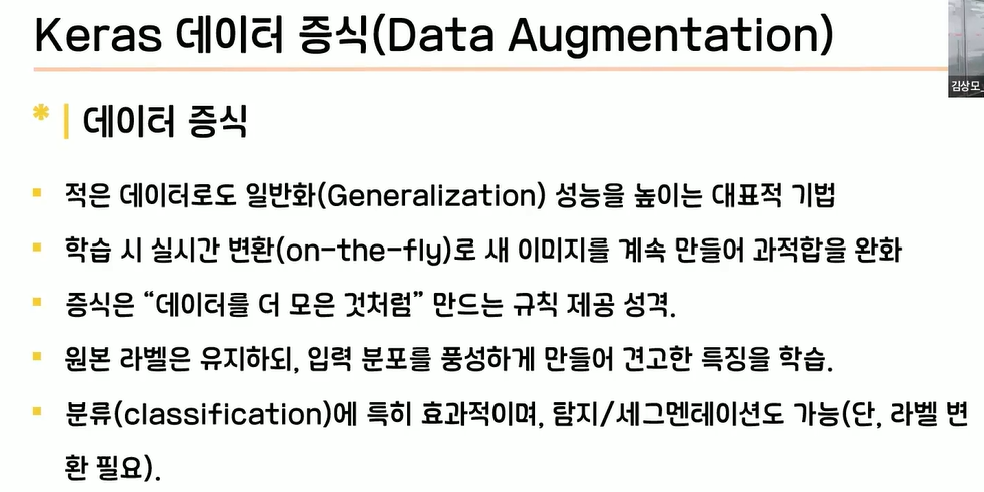

In [ ]:
# 예시 : 실행 X
# ImageDataGenerator : 변형 이미지 생성
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_flow = train_gen.flow_from_directory(
    'data/train', # 예시 : 하위에 cat, dog 이미지 파일
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary', # 다중 클래스면 categorical
    shuffle=True,
    seed=42
)

In [ ]:
# 고양이 이미지 증식 실습

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
import os

# preview 폴더 경로
preview_dir = './Test/preview'

if not os.path.exists(preview_dir):
    os.makedirs(preview_dir)

datagen = ImageDataGenerator(
    rotation_range=40,       # 이미지 자체를 회전(좌우 40도)
    width_shift_range=0.2,   # 이미지 좌우 이동
    height_shift_range=0.2,  # 이미지 위아래 이동
    shear_range=0.2,         # 이미지 비스듬하게
    zoom_range=0.2,          # 이미지 줌인, 줌아웃
    horizontal_flip=True,    # 이미지 중앙선 기준 좌우 반전
    fill_mode='nearest'      # 이미지 변경 후 빈 공간, 고양이 확대해서 채우기
)
img = load_img('./Test/cat/c1.jpg')

x = img_to_array(img) # (150, 150, 3)크기의 NumPy배열
# model.fit : input_shape에는 (150, 150, 3)만 지정
x = x.reshape((1,) + x.shape) # (1, 150, 150, 3)크기의 NumPy배열 -> flow()때문 : 여러 장의 이미지 배열을 받기 때문에, 몇 장인지 체크

# flow() : 임의 변환된 이미지를 배치 단위로 생성해서 지정된 './Test/preview/' 폴더에 저장
i=0
for batch in datagen.flow(x, batch_size=1, save_to_dir='./Test/preview', save_prefix='cat', save_format='jpeg'):
    i+=1
    if i>24:
        break

In [ ]:
# CNN마지막

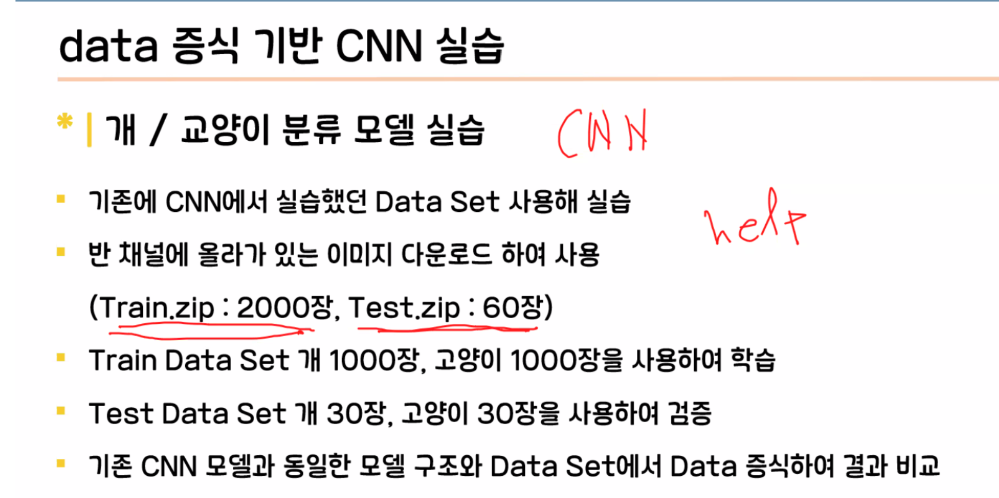

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
1600


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    65,028,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,030,017 (248.07 MB)

 Trainable params: 65,030,017 (248.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.7514 - loss: 2.9194
Epoch 1: val_loss improved from None to 0.01018, saving model to Model_CNN_Gen.keras

Epoch 1: finished saving model to Model_CNN_Gen.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 517ms/step - accuracy: 0.8819 - loss: 1.1521 - val_accuracy: 0.9974 - val_loss: 0.0102
Epoch 2/32
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9951 - loss: 0.0148
Epoch 2: val_loss improved from 0.01018 to 0.00413, saving model to Model_CNN_Gen.keras

Epoch 2: finished saving model to Model_CNN_Gen.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 452ms/step - accuracy: 0.9969 - loss: 0.0103 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 3/32
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9944 - loss: 0.0098
Epoch 3: val_loss improved from 0.00413 to 0.00260, saving model to Model_CNN_Gen.keras

Epoch 3: finished saving model to Model_CNN_Gen.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 442ms/step - accuracy: 0.9919 - loss: 0.0203 - va

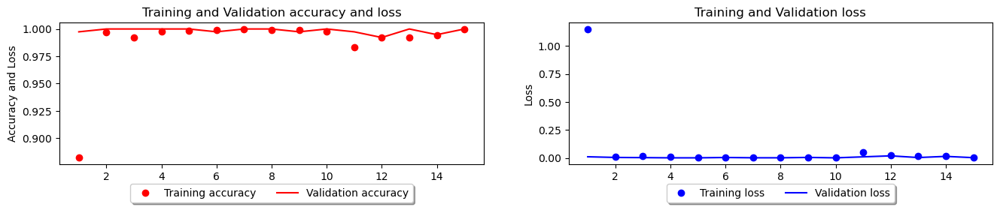

In [1]:
import os
import numpy
import tensorflow
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models, Input

rootPath = './Train/'

imageGenerator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    validation_split=0.2,
    fill_mode='nearest'
)

# flow_from_directory() : 폴더 구조 기준, 이미지를 읽어오고(학습 데이터), 자동으로 레이블(정답)을 붙여주는 함수
# Train/
# ├── cat/
# └── dog/
# cat : 클래스1
# dog : 클래스2로 자동 분류
trainGen = imageGenerator.flow_from_directory(
    os.path.join(rootPath, 'Train'),
    target_size=(128, 128),
    class_mode='binary',
    subset='training', # ImageDataGenerator에서 설정한 validation_split=0.2 기준, 전체 데이터 80%를 학습용으로 사용하겠다
    batch_size=32 # 생략시 32(default)
)

validationGen = imageGenerator.flow_from_directory(
    os.path.join(rootPath, 'Train'),
    target_size=(128, 128),
    class_mode='binary',
    subset='validation', # 전체 데이터 중 20%를 검증에 사용하겠다
    batch_size=32 # 생략시 32(default)
)

print(trainGen.samples) # 이미지 총 개수 확인

# 모델
# 128x128 크기의 컬러 이미지를 입력받는 CNN 이진 분류 모델입니다.
# Conv2D와 MaxPooling2D로 이미지의 특징을 추출하고, Flatten으로 1차원 형태로 변환합니다.
model = Sequential()
model.add(Input(shape=(128, 128, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 최적화
checkpointer = ModelCheckpoint(filepath="Model_CNN_Gen.keras", monitor='val_loss', verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(patience=5)

history = model.fit(
    trainGen,
    epochs=32,
    # imageGenerator 이미지 증강, 1epoch의 기준을 정해줘야 한다.
    # 1600/32 = 50
    # 32(batch_size)장씩 50번 돌리는게 1epoch
    steps_per_epoch = trainGen.samples // trainGen.batch_size,
    validation_data = validationGen,
    validation_steps = validationGen.samples // validationGen.batch_size,
    callbacks = [early_stopping_callback, checkpointer]
)

# 시각화
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(16, 1))

plt.subplot(121) # 행(1줄), 열(2줄), 배치(1번째)
plt.subplots_adjust(top=2)
plt.plot(epochs, accuracy, 'ro', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fancybox=True, shadow=True, ncol=5)

plt.subplot(122) # 행(1줄), 열(2줄), 배치(2번째)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fancybox=True, shadow=True, ncol=5)

plt.show()

In [ ]:
# 새로운 데이터로 예측 및 정확도 계산

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


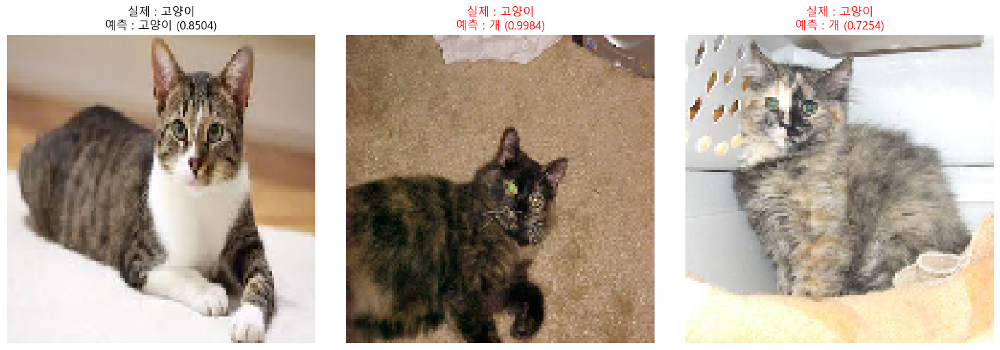

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


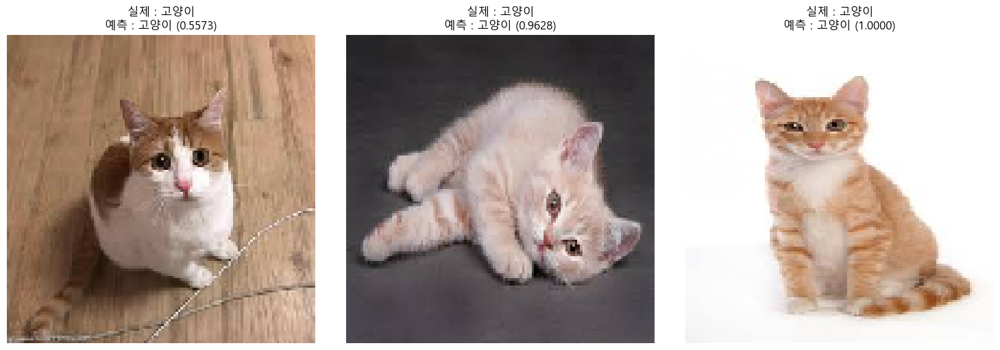

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


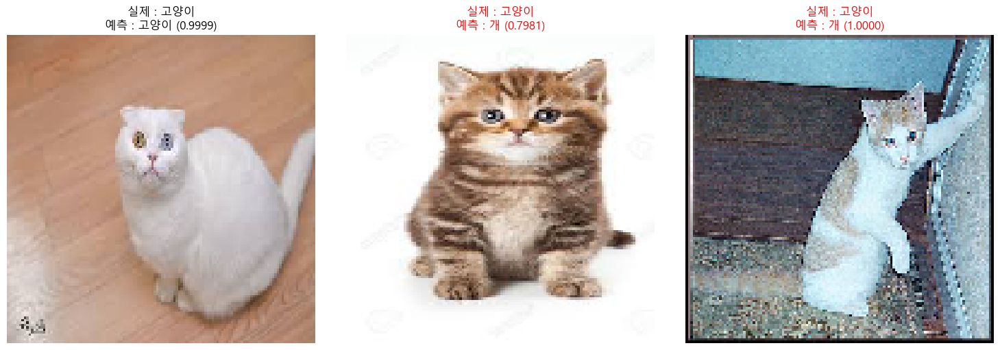

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


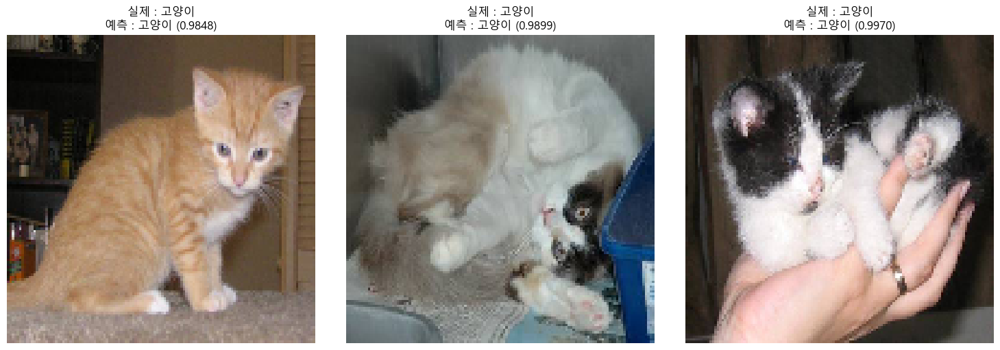

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


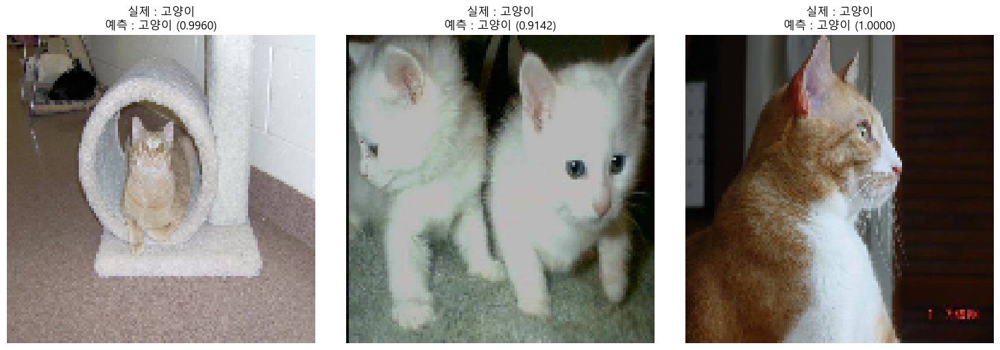

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


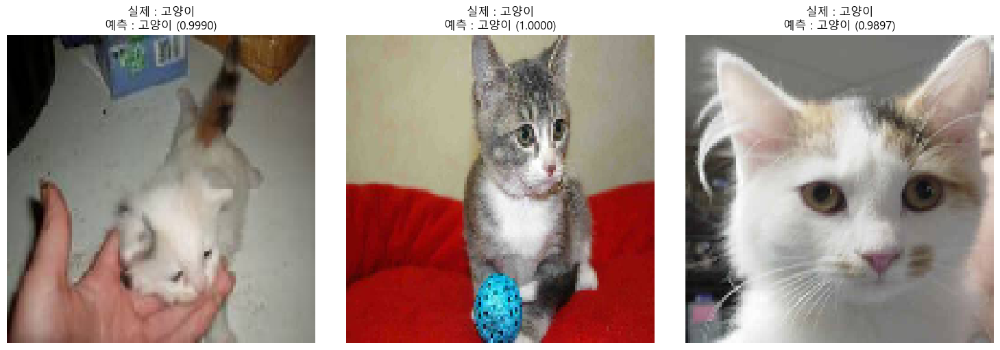

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


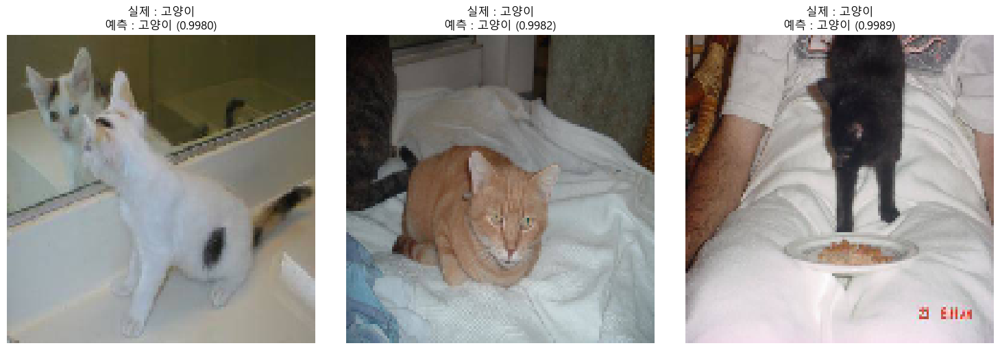

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


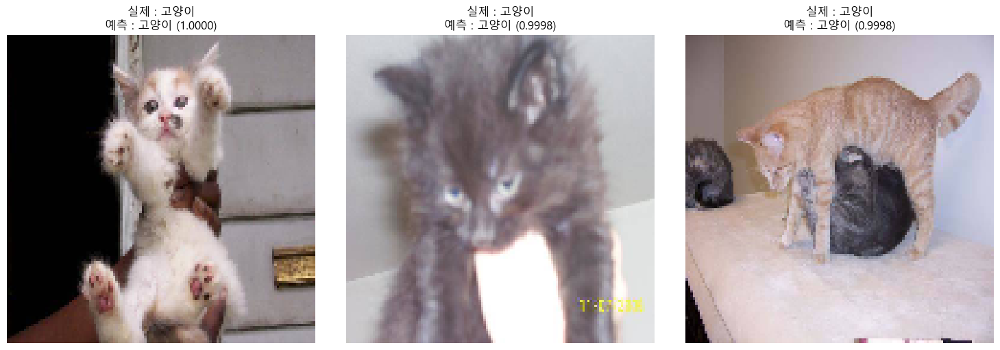

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


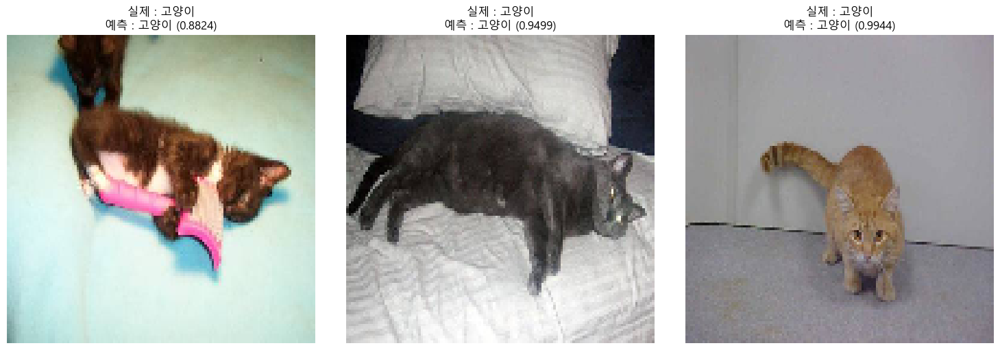

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


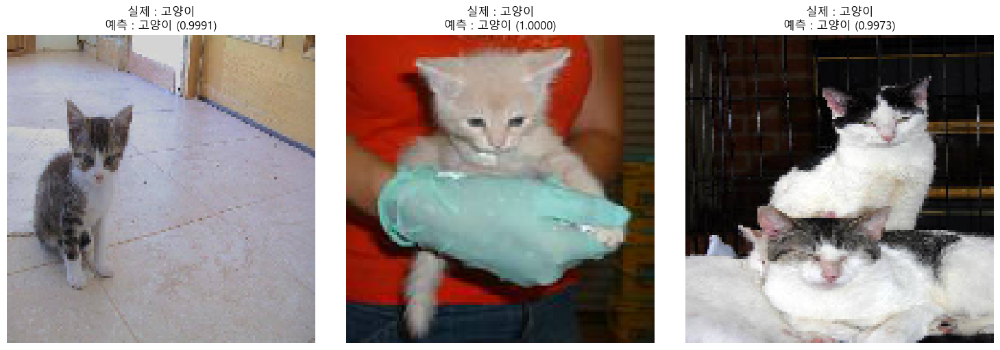

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


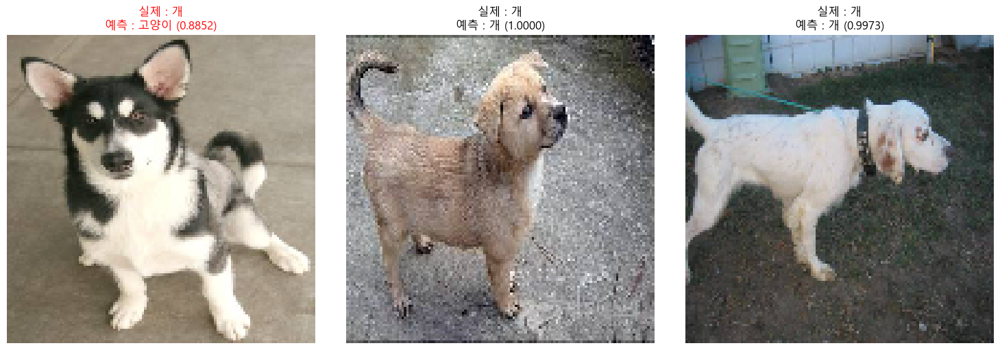

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


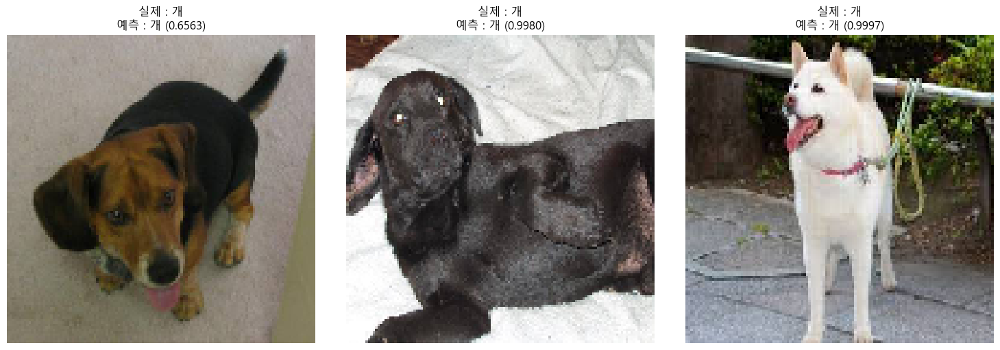

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


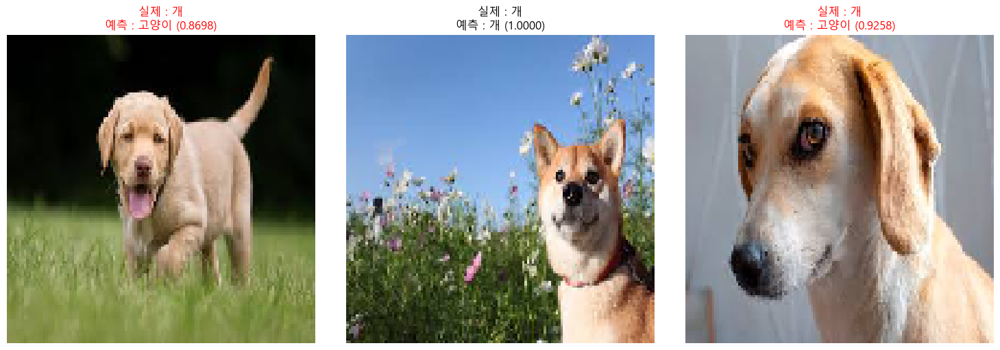

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


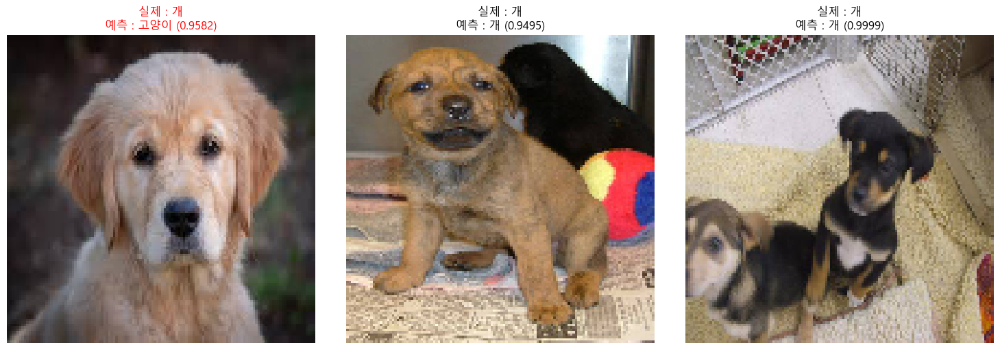

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


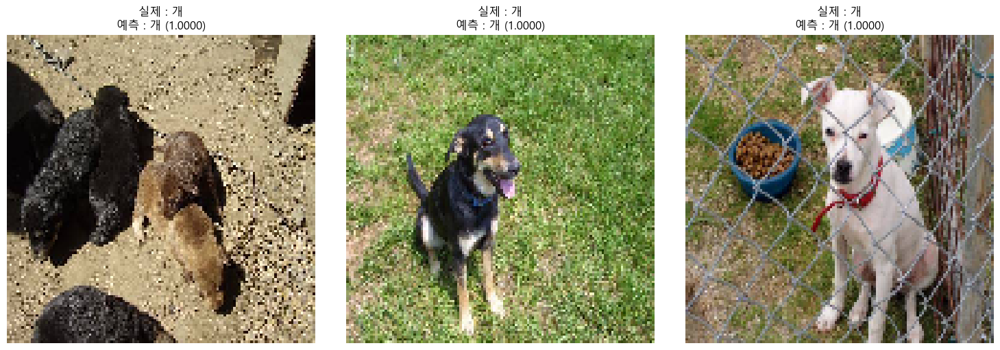

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


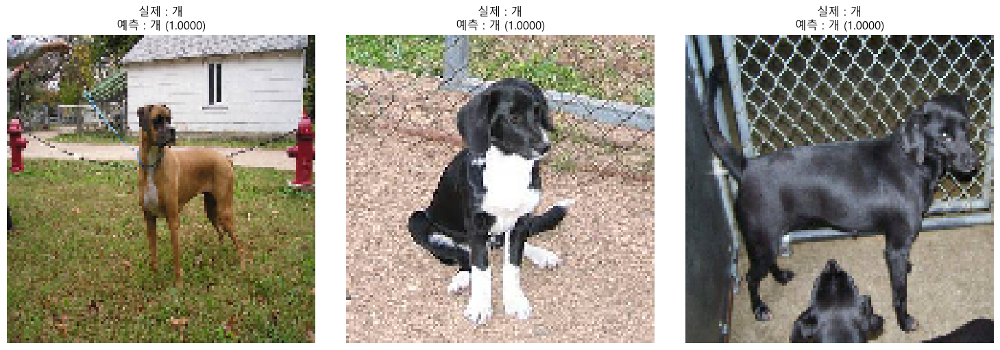

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


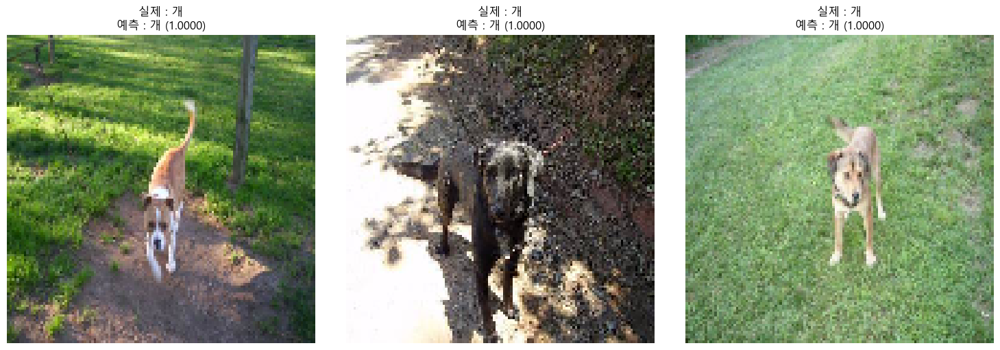

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


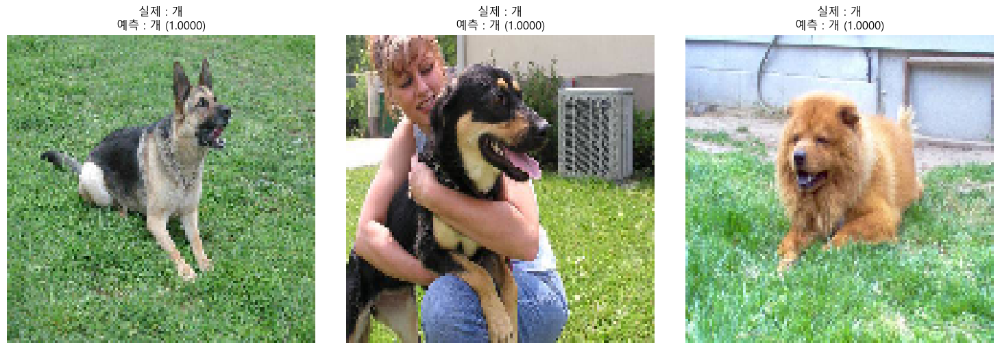

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


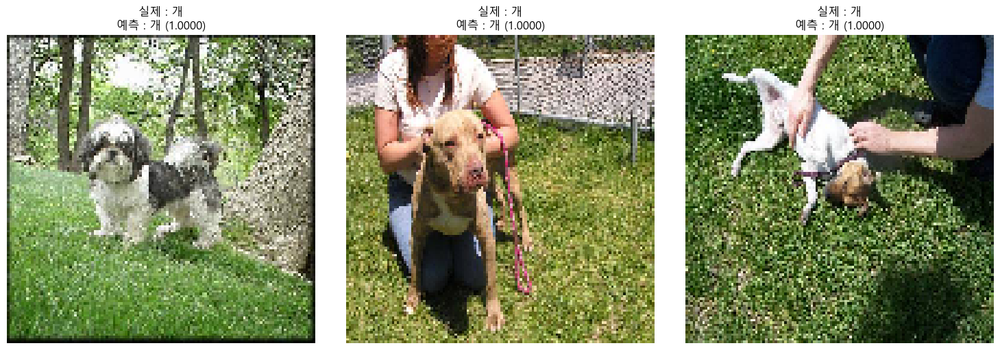

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


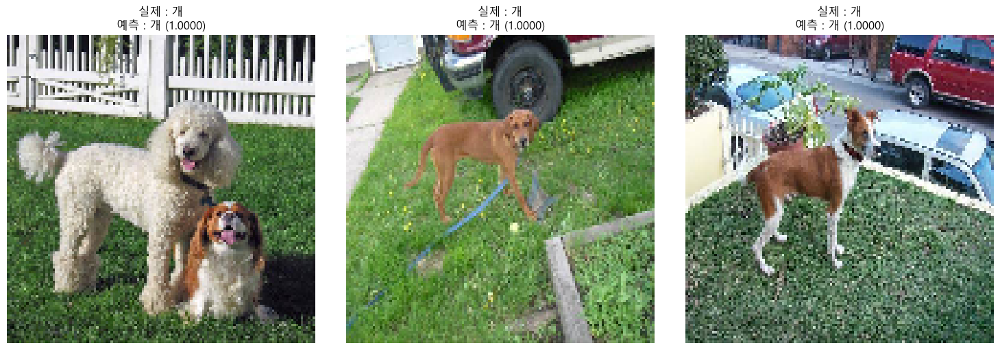


* 전체 정확도: 52/60 = 86.67%


In [2]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os

import matplotlib.font_manager as fm
# 한글 폰트 설정 (Windows 사용자용)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

cls_index = ['고양이', '개']
test_num = []

rootPath = './Test/Test'

# 고양이 이미지 불러오기
cat_folder = os.path.join(rootPath, 'cat')
for fname in os.listdir(cat_folder): # listdir() : 지정한 폴더 안의 파일들, 하위폴더의 '이름'을 '리스트'로 반환
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(cat_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128))
        test_num.append((img, 0))   # test_num = [(고양이 사진1, 0), (고양이 사진2, 0), (고양이 사진3, 0), ..., (고양이 사진1000, 0)]

# 개 이미지 불러오기
dog_folder = os.path.join(rootPath, 'dog')
for fname in os.listdir(dog_folder):
    if fname.lower().endswith('.jpg'):
        fpath = os.path.join(dog_folder, fname)
        img = image.load_img(fpath, target_size=(128, 128))
        test_num.append((img, 1))   # test_num = [(개 사진1, 1), (개 사진2, 1), (개 사진3, 1), ..., (개 사진1000, 1)]

# 예측 및 정확도 계산
correct = 0 # 몇 개 맞췄는지 저장하는 변수
cols = 3    # 몇 개씩 볼건지 저장하는 변수

for idx in range(0, len(test_num), cols): # idx위치를 cols만큼 건너뛴다. 0(idx):3, 3(idx):6, 6(idx):9,... 996(idx) : 999, 999(idx) : 1000
    batch = test_num[idx:idx + cols]
    fig, axes = plt.subplots(1, len(batch), figsize=(15, 5))

    if len(batch) == 1 : # 999(idx) : 1000(이미지 딱 1장) 처리
        axes = [axes]

    for i, (img, true_label) in enumerate(batch): # i : 0(enumerate), img = 이미지A, true_label = 0(고양이)
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        result = model.predict(img_array)[0][0] # [[0.8657]]
        pred_label = 1 if result >= 0.5 else 0
        pred_name = '개' if pred_label == 1 else '고양이'
        prob = result if pred_label == 1 else 1 - result
        true_name = '고양이' if true_label == 0 else '개'

        # 정확도 집계
        is_correct = (pred_label == true_label)
        if is_correct:
            correct += 1

        # 이미지 출력
        axes[i].imshow(img)
        axes[i].axis('off')
        title_color = 'black' if is_correct else 'red'
        axes[i].set_title(f"실제 : {true_name}\n예측 : {pred_name} ({prob:.4f})", fontsize=12, color=title_color)

    plt.tight_layout()
    plt.show()

# 전체 정확도 출력
accuracy = correct / len(test_num) * 100
print(f"\n* 전체 정확도: {correct}/{len(test_num)} = {accuracy:.2f}%")

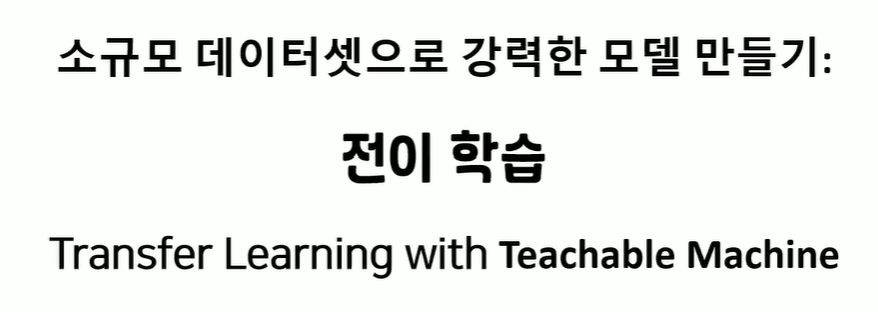

In [ ]:
# https://teachablemachine.withgoogle.com/
# teachablemachine : 구글이 거대한 데이터셋으로 학습시켜 둔 기본 모델
# 이미지 분류 : MobileNet
# 오디오 분류 : VGGish
# 포즈 인식 : PoseNet
# 모델 학습 내보내기는 .h2파일로 됨(사용 X)

In [ ]:
# 전이 학습(Transfer Learning) : 사전 학습된 모델의 지식을 새로운 문제에 적용하는 머신 러닝 기술
# 기존에 학습된 모델의 파라미터를 재사용한다.
# 사전 학습된 모델의 하위 레이어(새로운 문제)를 사용하여 새로운 데이터셋에 대한 특징을 추출

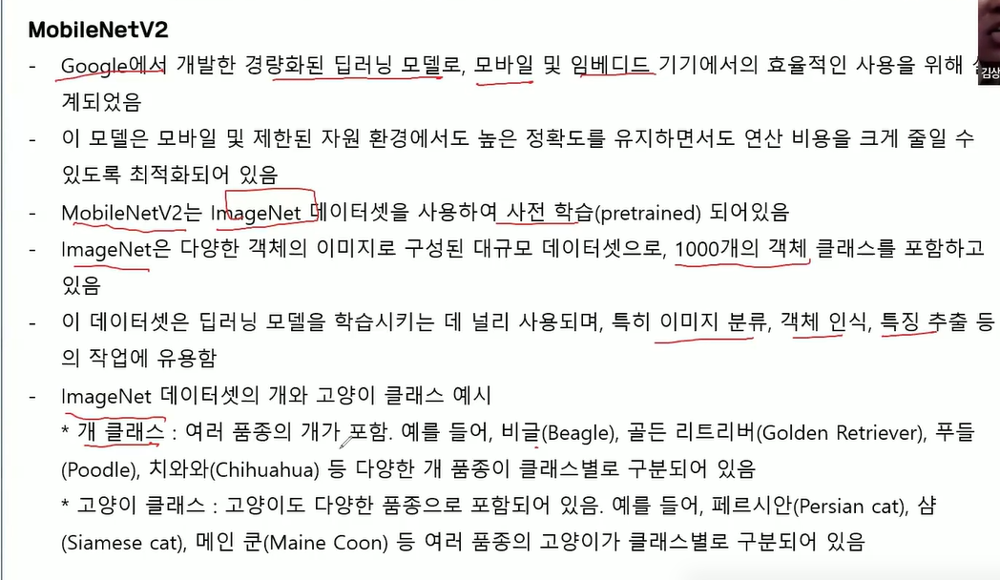

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2 # 전이학습 모듈
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

train_dir = './small_train'

# ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,    # 이미지 픽셀 값을 0-1 범위로 스케일링
    shear_range=0.2,      # 랜덤한 기울기 변환 적용
    zoom_range=0.2,       # 랜덤한 확대/축소 변환 적용
    horizontal_flip=True, # 랜덤하게 이미지를 좌우 반전
    validation_split=0.2  # 80% 학습, 20% 검증 데이터로 분리
)

# 학습데이터 생성기
# train/
# ├── cat/cat1.jpg
# └── dog/dog1.jpg
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='training' # 학습데이터 서브셋
)
# print(train_generator.class_indices)

# 검증데이터 생성기
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=8,
    class_mode='binary',
    subset='validation' # 검증데이터 서브셋 
)

# MobileNetV2 모델 불러오기
# imagenet에서 학습시킨 가중치 사용, 최상위 레이어(class)는 제거, input_shape = (가로, 세로, RGB)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 모델
x = base_model.output
# print("output:", base_model.output)
# print("pooling 전:", x)
x = GlobalAveragePooling2D()(x)
# print("pooling 후:", x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# 최종
# 사전 학습된 모델을 가져와서 사용(Transefer), Sequential부터 하나씩 연결 X
model = Model(inputs=base_model.input, outputs=predictions)

# model.compile(), model.fit()
# 전 단계로
# 이미 학습되어 가져온(Transfer) weights(가중치)를
# optimizer=adam이 바꾸지 않도록 설정
for layer in base_model.layers:
    layer.trainable = False

# model.compile()
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# model.fit()
# ceil() : '올림'함수
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples//validation_generator.batch_size,
    epochs=10 # 에포크 수
)

model.save('cat_dog_classifier.keras')

Found 56 images belonging to 2 classes.
Found 14 images belonging to 2 classes.
output: <KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_618>
pooling 전: <KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_618>
pooling 후: <KerasTensor shape=(None, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_619>
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 536ms/step - accuracy: 0.7857 - loss: 0.4696 - val_accuracy: 1.0000 - val_loss: 0.1893
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 1.0000 - loss: 0.1080 - val_accuracy: 1.0000 - val_loss: 0.0536
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 1.0000 - loss: 0.0364 - val_accuracy: 1.0000 - val_loss: 0.0506
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 1.0000 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 0.0361
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 1.0000 - loss:

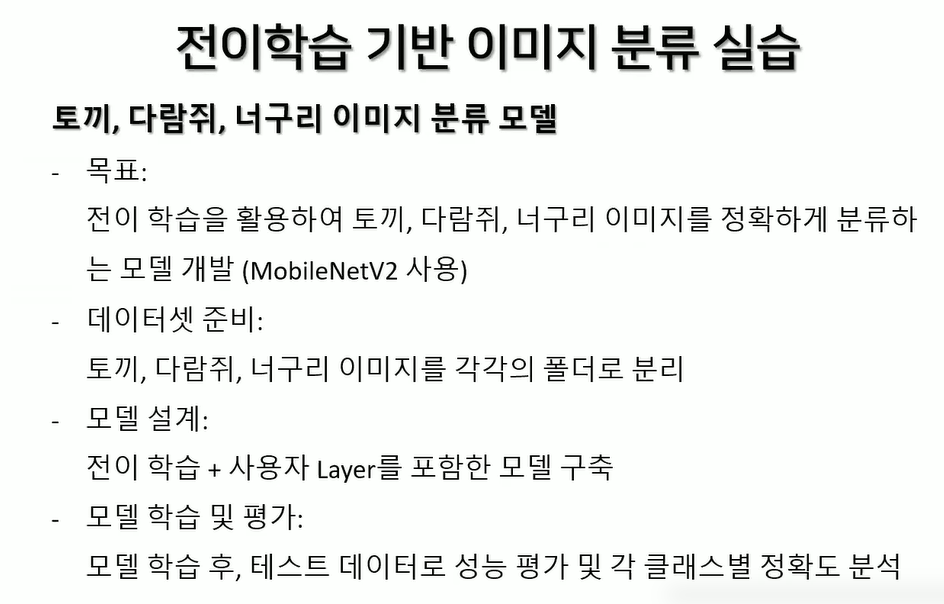

In [9]:
import tensorflow as tf
import os
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

base_dir = './animal_dataset/train'
img_size = (224, 224)
batch_size = 32

# ImageDataGenerator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# train_generator
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True # 이미지 읽어올 때 순서 섞기, train O
)

# validation_generator
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False # 이미지 읽어올 때 순서 섞기, validate X
)

# MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# 이미 학습되어있는 모델(Transfer)의 가중치 고정(새로 학습 X)
base_model.trainable = False

# 모델
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# model.compile()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 최적화
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
model_path = "best_animal_model.keras"
checkpoint = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss')

# model.fit()
history = model.fit(
    train_generator,
    # steps_per_epoch=train_generator.samples//train_generator.batch_size,
    validation_data=val_generator,
    # validation_steps=val_generator.samples//val_generator.batch_size,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

# 예측
val_generator.reset() # 리셋 : model.fit()에서 사용된 val_generator
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# 클래스별 정확도
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Found 24 images belonging to 3 classes.
Found 6 images belonging to 3 classes.
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 34s 34s/step - accuracy: 0.2917 - loss: 1.8100 - val_accuracy: 0.8333 - val_loss: 0.8074
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 0.5833 - loss: 0.7613 - val_accuracy: 0.6667 - val_loss: 0.6690
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 0.9167 - loss: 0.3201 - val_accuracy: 0.6667 - val_loss: 0.5252
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 1.0000 - loss: 0.1883 - val_accuracy: 0.8333 - val_loss: 0.3474
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 1.0000 - loss: 0.1031 - val_accuracy: 1.0000 - val_loss: 0.2499
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 1.0000 - loss: 0.0790 - val_accuracy: 1.0000 - val_loss: 0.1885
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step - accuracy: 1.0000 - loss: 0.0337 - val_accuracy: 1.0000 - val_loss: 0.1574
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/st